In [ ]:
# from eppy.modeleditor import IDF
# import os

# # Load IDD first
# iddfile = "/usr/local/EnergyPlus-9-5-0/Energy+.idd"
# idf_path = "/workspaces/CUBES/beizaee_validation/building_model.idf"

# EPLUS_PATH = "/usr/local/EnergyPlus-9-5-0/"
# iddfile = os.path.join(EPLUS_PATH, "Energy+.idd")
# IDF.setiddname(iddfile)
# idf = IDF(idf_path)



# def get_material_r_value(material):
#     thickness = float(material.Thickness)
#     conductivity = float(material.Conductivity)
#     return thickness / conductivity if conductivity > 0 else 0

# u_values = {}

# for construction in idf.idfobjects["CONSTRUCTION"]:
#     r_total = 0
#     for i in range(1, 11):  # Up to 10 layers
#         field = f"Layer_{i}"
#         if hasattr(construction, field):
#             material_name = getattr(construction, field)
#             if not material_name:
#                 continue
#             material = idf.getobject("MATERIAL", material_name.upper())
#             if material:
#                 r_total += get_material_r_value(material)

#     # Add surface resistances
#     r_total += 0.13 + 0.04  # Rsi + Rse

#     if r_total > 0:
#         u_value = 1 / r_total
#         u_values[construction.Name] = round(u_value, 3)

# # Show results
# for name, u in u_values.items():
#     print(f"{name}: U = {u} W/m²K")



# --- MATERIAL DEFINITIONS BASED ON BEIZAEE ---

# materials = [
#     ("BrickOuter_beizaee",        0.105, 0.84, 800, 1700),
#     ("BrickInner_beizaee",        0.105, 0.62, 800, 1700),
#     ("DensePlaster_beizaee",      0.013, 0.50, 1000, 1300),
#     ("TimberFlooring_beizaee",    0.02,  0.14, 1200, 650),
#     ("Carpet_beizaee",            0.005, 0.06, 1300, 200),
#     ("CastConcrete_beizaee",      0.1,   1.13, 1000, 2000),
#     ("Plasterboard_beizaee",      0.013, 0.25, 896, 2800),
#     ("ClayTile_beizaee",          0.025, 1.00, 800, 2000),
#     ("RoofingFelt_beizaee",       0.005, 0.19, 837, 960),
#     ("Glass_beizaee",             0.003, 0.90, 2500, 750),
#     ("Polyiso_beizaee",           0.05,  0.022, 1470, 45),
#     ("Oak_beizaee",               0.044, 0.19, 2390, 700),
#     ("AirGap_beizaee",            0.07,  0.026, 1.2, 1000),  # Generic air layer
# ]

# for name, thickness, conductivity, density, specific_heat in materials:
#     idf.newidfobject("MATERIAL",
#         Name=name,
#         Roughness="MediumSmooth",
#         Thickness=thickness,
#         Conductivity=conductivity,
#         Density=density,
#         Specific_Heat=specific_heat
#     )

# --- CONSTRUCTION OBJECTS USING THESE MATERIALS ---

# constructions = {
#     "ExternalWall_beizaee": ["BrickOuter_beizaee", "AirGap_beizaee", "BrickInner_beizaee", "DensePlaster_beizaee"],
#     "InternalPartitionWall_beizaee": ["DensePlaster_beizaee", "BrickInner_beizaee", "DensePlaster_beizaee"],
#     "PartyWall_beizaee": ["DensePlaster_beizaee", "BrickInner_beizaee", "AirGap_beizaee", "BrickInner_beizaee", "DensePlaster_beizaee"],
#     "SemiExposedGroundFloor_beizaee": ["TimberFlooring_beizaee", "Carpet_beizaee"],
#     "SolidKitchenFloor_beizaee": ["CastConcrete_beizaee"],
#     "InternalFloor_beizaee": ["Plasterboard_beizaee", "AirGap_beizaee", "TimberFlooring_beizaee", "Carpet_beizaee"],
#     "FirstFloorCeiling_beizaee": ["Plasterboard_beizaee"],
#     "PitchedRoof_beizaee": ["ClayTile_beizaee", "AirGap_beizaee", "RoofingFelt_beizaee"],
#     "SingleGlazing_beizaee": ["Glass_beizaee"],
#     "WindowWithInsulation_beizaee": ["Glass_beizaee", "AirGap_beizaee", "Polyiso_beizaee"],
#     "Door_beizaee": ["Oak_beizaee"]
# }

# for name, layers in constructions.items():
#     idf.newidfobject("CONSTRUCTION",
#         Name=name,
#         Outside_Layer=layers[0],
#         Layer_2=layers[1] if len(layers) > 1 else "",
#         Layer_3=layers[2] if len(layers) > 2 else "",
#         Layer_4=layers[3] if len(layers) > 3 else "",
#         Layer_5=layers[4] if len(layers) > 4 else ""
#     )

# --- OPTIONAL: Map current construction names to Beizaee versions ---

# replacement_map = {
#     "Wall-Construction": "ExternalWall_beizaee",
#     "InternalWall-Construction": "InternalPartitionWall_beizaee",
#     "Adiabatic Wall-Construction": "PartyWall_beizaee",
#     "GroundFloor-Construction": "SemiExposedGroundFloor_beizaee",
#     "Floor-Construction": "InternalFloor_beizaee",
#     "Ceiling-Construction": "FirstFloorCeiling_beizaee",
#     "Roof-Construction": "PitchedRoof_beizaee",
#     "Last floor-Construction": "InternalFloor_beizaee",
#     "Last ceiling-Construction": "FirstFloorCeiling_beizaee",
#     "Single Glazing": "SingleGlazing_beizaee"
# }

# for surface in idf.idfobjects["BUILDINGSURFACE:DETAILED"]:
#     old = surface.Construction_Name
#     if old in replacement_map:
#         surface.Construction_Name = replacement_map[old]

# # Save it
# idf.saveas("building_model.idf")

def adjust_infiltration_by_path(idf_path, factor=1.0, eplus_path="/usr/local/EnergyPlus-9-5-0/"):
    """
    Loads an IDF file, adjusts infiltration rates by a specified factor, and saves it back to the same path.

    Args:
        idf_path (str): Path to the IDF file.
        factor (float): Multiplicative factor for infiltration rates (e.g., 1.2 = +20%).
        eplus_path (str): Path to EnergyPlus installation containing Energy+.idd.

    Returns:
        None
    """
    import os
    from eppy.modeleditor import IDF

    # Set IDD
    iddfile = os.path.join(eplus_path, "Energy+.idd")
    IDF.setiddname(iddfile)

    # Load IDF
    idf = IDF(idf_path)

    # Adjust infiltration
    # infiltration_objects = idf.idfobjects["ZONEINFILTRATION:DESIGNFLOWRATE"]

    # if not infiltration_objects:
    #     print("⚠️ No infiltration objects found in the IDF.")
    #     return

    # for infil in infiltration_objects:
    #     original_value = float(infil.Design_Flow_Rate)
    #     infil.Design_Flow_Rate = original_value * factor
    #     print(f"Updated {infil.Name}: {original_value:.6f} → {infil.Design_Flow_Rate:.6f}")

    # # Save directly to the same path
    # idf.saveas(idf_path)
    # print(f"✅ Overwritten IDF with updated infiltration rates at: {idf_path}")

    return idf



# Increase infiltration by 10% and overwrite the file
idf = adjust_infiltration_by_path("/workspaces/CUBES/beizaee_validation/building_model.idf", factor=1.1)





In [ ]:
afn_control = idf.newidfobject("AIRFLOWNETWORK:MULTIZONE:SURFACE")
print(afn_control.fieldnames)


In [ ]:
import os
from collections import defaultdict
from eppy.modeleditor import IDF

def load_idf(idf_path, eplus_path):
    """Load IDF with correct IDD."""
    iddfile = os.path.join(eplus_path, "Energy+.idd")
    IDF.setiddname(iddfile)
    idf = IDF(idf_path)
    print("✅ Loaded IDF successfully.")
    return idf


def ensure_basic_schedules(idf):
    """Ensure AlwaysOnSchedule and AlwaysOffSchedule exist."""
    existing_schedules = {s.Name.lower() for s in idf.idfobjects.get("SCHEDULE:CONSTANT", [])}

    if "alwaysonschedule" not in existing_schedules:
        idf.newidfobject(
            "SCHEDULE:CONSTANT",
            Name="AlwaysOnSchedule",
            Schedule_Type_Limits_Name="OnOff",
            Hourly_Value=1
        )
        print("🗓️ Added AlwaysOnSchedule.")

    if "alwaysoffschedule" not in existing_schedules:
        idf.newidfobject(
            "SCHEDULE:CONSTANT",
            Name="AlwaysOffSchedule",
            Schedule_Type_Limits_Name="OnOff",
            Hourly_Value=0
        )
        print("🗓️ Added AlwaysOffSchedule.")


def remove_old_airflow_objects(idf):
    """Remove old infiltration, ventilation, and cross-mixing objects safely."""
    for objtype in ["ZONEINFILTRATION:DESIGNFLOWRATE", "ZONEVENTILATION:DESIGNFLOWRATE", "ZONECROSSMIXING"]:
        old_objects = list(idf.idfobjects.get(objtype, []))  # Make a copy!
        for obj in old_objects:
            idf.removeidfobject(obj)
    print("🗑️ Removed old infiltration, ventilation, and mixing objects.")


def setup_afn_control(idf):
    """Set up AFN simulation controls and basic settings."""
    cp_array_name = "NormalExposureCpArray"
    idf.newidfobject(
        "AIRFLOWNETWORK:SIMULATIONCONTROL",
        Name="AFN_SimulationControl",
        AirflowNetwork_Control="MultizoneWithoutDistribution",
        Wind_Pressure_Coefficient_Type="Input",
        Height_Selection_for_Local_Wind_Pressure_Calculation="ExternalNode",
        Building_Type="LowRise",
        Maximum_Number_of_Iterations=500,
        Initialization_Type="ZeroNodePressures",
        Relative_Airflow_Convergence_Tolerance=1e-5,
        Absolute_Airflow_Convergence_Tolerance=1e-6,
        Convergence_Acceleration_Limit=-0.5,
        Azimuth_Angle_of_Long_Axis_of_Building=0,
        Ratio_of_Building_Width_Along_Short_Axis_to_Width_Along_Long_Axis=1,
        Height_Dependence_of_External_Node_Temperature="No"
    )
    idf.newidfobject(
        "AIRFLOWNETWORK:MULTIZONE:WINDPRESSURECOEFFICIENTARRAY",
        Name=cp_array_name,
        Wind_Direction_1=0, Wind_Direction_2=45, Wind_Direction_3=90, Wind_Direction_4=135,
        Wind_Direction_5=180, Wind_Direction_6=225, Wind_Direction_7=270, Wind_Direction_8=315
    )
    if not idf.idfobjects.get("AIRFLOWNETWORK:MULTIZONE:REFERENCECRACKCONDITIONS"):
        idf.newidfobject(
            "AIRFLOWNETWORK:MULTIZONE:REFERENCECRACKCONDITIONS",
            Name="ReferenceCrackConditions",
            Reference_Temperature=20.0,
            Reference_Barometric_Pressure=101325,
            Reference_Humidity_Ratio=0.0
        )
    for zone in idf.idfobjects["ZONE"]:
        idf.newidfobject(
            "AIRFLOWNETWORK:MULTIZONE:ZONE",
            Zone_Name=zone.Name,
            Ventilation_Control_Mode="Constant",
            Minimum_Venting_Open_Factor=1,
            Indoor_and_Outdoor_Temperature_Difference_Lower_Limit_For_Maximum_Venting_Open_Factor=0,
            Indoor_and_Outdoor_Temperature_Difference_Upper_Limit_for_Minimum_Venting_Open_Factor=100,
            Indoor_and_Outdoor_Enthalpy_Difference_Lower_Limit_For_Maximum_Venting_Open_Factor=0,
            Indoor_and_Outdoor_Enthalpy_Difference_Upper_Limit_for_Minimum_Venting_Open_Factor=100000,
            Venting_Availability_Schedule_Name="AlwaysOnSchedule",
            Single_Sided_Wind_Pressure_Coefficient_Algorithm="Standard",
            Facade_Width=0
        )
    print("🔧 AFN controls set up.")

def calculate_surface_mid_height(surface):
    zcoords = [float(getattr(surface, f"Vertex_{i}_Zcoordinate")) for i in range(1, 5) if getattr(surface, f"Vertex_{i}_Zcoordinate", "") != ""]
    return sum(zcoords) / len(zcoords) if zcoords else 1.5

def is_surface_horizontal(surface):
    zcoords = [float(getattr(surface, f"Vertex_{i}_Zcoordinate")) for i in range(1, 5) if getattr(surface, f"Vertex_{i}_Zcoordinate", "") != ""]
    return (max(zcoords) - min(zcoords)) < 0.1 if len(zcoords) >= 2 else False

def get_door_schedule(name):
    name = name.lower()
    if "kitchen" in name:
        return "door-open-schedule-kitchen"
    elif "backroom" in name:
        return "door-schedule-backroom"
    elif "front_room" in name:
        return "door-schedule-front_room"
    elif "bathroom" in name:
        return "door-schedule-bathroom"
    elif "bedroom_1" in name:
        return "door-schedule-bedroom_1"
    elif "bedroom_2" in name:
        return "door-schedule-bedroom_2"
    elif "bedroom_3" in name:
        return "door-schedule-bedroom_3"
    elif "wash_closet" in name:
        return "door-schedule-wash_closet"
    elif "wall" in name:
        return "AlwaysOffSchedule"
    else:
        return "AlwaysOnSchedule"

def pair_internal_doors(fenestrations):
    """Pairs internal doors based on their Outside Boundary Condition Object."""
    pairs = []
    paired = set()

    # Only keep fenestrations that are actually internal doors
    door_fens = [fen for fen in fenestrations if fen.Surface_Type.lower() == "door" and "partition" in fen.Name.lower()]

    # Create a lookup dictionary for fast matching
    fen_lookup = {fen.Name: fen for fen in door_fens}

    for fen in door_fens:
        if fen.Name in paired:
            continue

        other = fen.Outside_Boundary_Condition_Object
        if other and other in fen_lookup:
            pairs.append((fen, fen_lookup[other]))
            paired.add(fen.Name)
            paired.add(other)
        else:
            pairs.append((fen, None))
            paired.add(fen.Name)

    return pairs

def add_cracks_to_building_surfaces(idf, cp_array_name):
    """Add cracks and external nodes to external walls and roofs."""
    # Crack coefficients for different building elements (from the thesis)
    crack_characteristics = {
        'external_wall': {'flow_coef': 0.0002, 'exponent': 0.7},
        'internal_wall': {'flow_coef': 0.005, 'exponent': 0.75},  # Updated for internal walls
        'internal_floor': {'flow_coef': 0.002, 'exponent': 0.7},
        'external_floor': {'flow_coef': 0.001, 'exponent': 1.0},
        'roof': {'flow_coef': 0.00015, 'exponent': 0.7}
    }

    count = 0
    for surface in idf.idfobjects["BUILDINGSURFACE:DETAILED"]:
        if surface.Outside_Boundary_Condition.lower() != "outdoors":
            continue

        # Choose crack properties based on surface type
        surface_type = surface.Surface_Type.lower()
        if surface_type == "wall":
            crack_flow_coef, crack_exponent = crack_characteristics['external_wall'].values()
        elif surface_type == "roof":
            crack_flow_coef, crack_exponent = crack_characteristics['roof'].values()
        elif surface_type == "floor":
            if "external" in surface.Name.lower():
                crack_flow_coef, crack_exponent = crack_characteristics['external_floor'].values()
            else:
                crack_flow_coef, crack_exponent = crack_characteristics['internal_floor'].values()
        elif surface_type == "internalwall":  # Add check for internal walls
            crack_flow_coef, crack_exponent = crack_characteristics['internal_wall'].values()  # Internal wall properties
        else:
            continue  # Skip if no matching surface type

        idf.newidfobject(
            "AIRFLOWNETWORK:MULTIZONE:SURFACE:CRACK",
            Name=f"{surface.Name}_Crack",
            Air_Mass_Flow_Coefficient_at_Reference_Conditions=crack_flow_coef,
            Air_Mass_Flow_Exponent=crack_exponent,
            Reference_Crack_Conditions="ReferenceCrackConditions"
        )
        idf.newidfobject(
            "AIRFLOWNETWORK:MULTIZONE:SURFACE",
            Surface_Name=surface.Name,
            Leakage_Component_Name=f"{surface.Name}_Crack",
            External_Node_Name=surface.Name,
            Ventilation_Control_Mode="ZoneLevel"
        )
        count += 1
    return count



def add_cracks_to_building_surfaces(idf, crack_flow_coef, crack_exponent, cp_array_name):
    """Add cracks and external nodes to external walls and roofs."""
    cp_values_wall = [0.4, 0.1, -0.3, -0.35, -0.2, -0.35, -0.3, -0.1]
    cp_values_roof = [-0.6, -0.5, -0.4, -0.5, -0.6, -0.5, -0.4, -0.5]

    count = 0
    for surface in idf.idfobjects["BUILDINGSURFACE:DETAILED"]:
        if surface.Outside_Boundary_Condition.lower() != "outdoors":
            continue

        cp_values = cp_values_wall if surface.Surface_Type.lower() == "wall" else cp_values_roof

        idf.newidfobject(
            "AIRFLOWNETWORK:MULTIZONE:WINDPRESSURECOEFFICIENTVALUES",
            Name=surface.Name,
            AirflowNetworkMultiZoneWindPressureCoefficientArray_Name=cp_array_name,
            **{f"Wind_Pressure_Coefficient_Value_{i+1}": v for i, v in enumerate(cp_values)}
        )
        idf.newidfobject(
            "AIRFLOWNETWORK:MULTIZONE:EXTERNALNODE",
            Name=surface.Name,
            External_Node_Height=calculate_surface_mid_height(surface),
            Wind_Pressure_Coefficient_Curve_Name=surface.Name
        )

        idf.newidfobject(
            "AIRFLOWNETWORK:MULTIZONE:SURFACE:CRACK",
            Name=f"{surface.Name}_Crack",
            Air_Mass_Flow_Coefficient_at_Reference_Conditions=crack_flow_coef,
            Air_Mass_Flow_Exponent=crack_exponent,
            Reference_Crack_Conditions="ReferenceCrackConditions"
        )
        idf.newidfobject(
            "AIRFLOWNETWORK:MULTIZONE:SURFACE",
            Surface_Name=surface.Name,
            Leakage_Component_Name=f"{surface.Name}_Crack",
            External_Node_Name=surface.Name,
            Ventilation_Control_Mode="ZoneLevel"
        )
        count += 1
    return count

def add_cracks_to_external_fenestrations(idf, crack_flow_coef, crack_exponent):
    """Add cracks to external windows, vents, and external doors (not internal doors)."""
    count = 0
    building_surfaces = idf.idfobjects["BUILDINGSURFACE:DETAILED"]
    for fen in idf.idfobjects["FENESTRATIONSURFACE:DETAILED"]:
        if (fen.Surface_Type.lower() == "door" and "partition" in fen.Name.lower()) or 'hole' in fen.Name.lower():
            continue

        parent = next((s for s in building_surfaces if s.Name == fen.Building_Surface_Name), None)
        if not parent or parent.Outside_Boundary_Condition.lower() != "outdoors":
            continue

        idf.newidfobject(
            "AIRFLOWNETWORK:MULTIZONE:SURFACE:CRACK",
            Name=f"{fen.Name}_Crack",
            Air_Mass_Flow_Coefficient_at_Reference_Conditions=crack_flow_coef,
            Air_Mass_Flow_Exponent=crack_exponent,
            Reference_Crack_Conditions="ReferenceCrackConditions"
        )
        idf.newidfobject(
            "AIRFLOWNETWORK:MULTIZONE:SURFACE",
            Surface_Name=fen.Name,
            Leakage_Component_Name=f"{fen.Name}_Crack",
            External_Node_Name=parent.Name,
            Ventilation_Control_Mode="ZoneLevel"
        )
        count += 1
    return count

def add_horizontal_openings_for_holes(idf):
    """Add horizontal openings for _hole surfaces, pairing duplicates properly."""
    count = 0
    building_surfaces = idf.idfobjects["BUILDINGSURFACE:DETAILED"]
    fenestrations = idf.idfobjects["FENESTRATIONSURFACE:DETAILED"]

    # Filter only _hole fenestrations
    hole_fens = [fen for fen in fenestrations if "_hole" in fen.Name.lower()]

    # Pair them
    pairs = []
    paired = set()
    fen_lookup = {fen.Name: fen for fen in hole_fens}

    for fen in hole_fens:
        if fen.Name in paired:
            continue

        other = fen.Outside_Boundary_Condition_Object
        if other and other in fen_lookup:
            pairs.append((fen, fen_lookup[other]))
            paired.add(fen.Name)
            paired.add(other)
        else:
            pairs.append((fen, None))
            paired.add(fen.Name)

    # Now process each pair
    for fen1, fen2 in pairs:
        # Pick first fenestration in the pair
        selected = fen1  # You could add smarter logic, but this is fine for now

        parent = next((s for s in building_surfaces if s.Name == selected.Building_Surface_Name), None)

        idf.newidfobject(
            "AIRFLOWNETWORK:MULTIZONE:COMPONENT:HORIZONTALOPENING",
            Name=f"{selected.Name}_Opening",
            Air_Mass_Flow_Coefficient_When_Opening_is_Closed=0.001,
            Air_Mass_Flow_Exponent_When_Opening_is_Closed=0.65,
            Sloping_Plane_Angle=90.0,
            Discharge_Coefficient=0.2
        )
        idf.newidfobject(
            "AIRFLOWNETWORK:MULTIZONE:SURFACE",
            Surface_Name=selected.Name,
            Leakage_Component_Name=f"{selected.Name}_Opening",
            External_Node_Name="",
            Ventilation_Control_Mode="Constant",
            Venting_Availability_Schedule_Name="AlwaysOnSchedule"
        )
        count += 1

    print(f"🔵 Horizontal Openings Created: {count}")
    return count


def add_simple_openings_for_internal_doors(idf):
    """Add SimpleOpenings to internal doors, picking the right door schedule."""
    count = 0
    building_surfaces = idf.idfobjects["BUILDINGSURFACE:DETAILED"]
    fenestration_surfaces = idf.idfobjects["FENESTRATIONSURFACE:DETAILED"]
    internal_door_pairs = pair_internal_doors(fenestration_surfaces)

    for door1, door2 in internal_door_pairs:
        candidates = [d for d in (door1, door2) if d]
        selected = None

        for door in candidates:
            if "hall" not in door.Name.lower():
                selected = door
                break
        if not selected:
            selected = candidates[0]

        parent = next((s for s in building_surfaces if s.Name == selected.Building_Surface_Name), None)

        idf.newidfobject(
            "AIRFLOWNETWORK:MULTIZONE:COMPONENT:SIMPLEOPENING",
            Name=f"{selected.Name}_Opening",
            Air_Mass_Flow_Coefficient_When_Opening_is_Closed=0.001,
            Air_Mass_Flow_Exponent_When_Opening_is_Closed=0.65,
            Minimum_Density_Difference_for_TwoWay_Flow=0.0001,
            Discharge_Coefficient=0.65
        )
        idf.newidfobject(
            "AIRFLOWNETWORK:MULTIZONE:SURFACE",
            Surface_Name=selected.Name,
            Leakage_Component_Name=f"{selected.Name}_Opening",
            External_Node_Name="",
            Ventilation_Control_Mode="Constant",
            Venting_Availability_Schedule_Name=get_door_schedule(selected.Name)
        )
        count += 1
    return count

def add_cracks_and_openings(idf):
    """Adds cracks and openings to IDF for AFN model."""
    crack_flow_coef = 0.0002
    crack_exponent = 0.7
    cp_array_name = "NormalExposureCpArray"

    external = add_cracks_to_building_surfaces(idf, crack_flow_coef, crack_exponent, cp_array_name)
    fenestrations = add_cracks_to_external_fenestrations(idf, crack_flow_coef, crack_exponent)
    holes = add_horizontal_openings_for_holes(idf)
    internals = add_simple_openings_for_internal_doors(idf)

    print(f"🔵 External Surfaces with Cracks: {external}")
    print(f"🔵 External Fenestrations with Cracks: {fenestrations}")
    print(f"🔵 Horizontal Openings Created: {holes}")
    print(f"🔵 Internal Door Openings Created: {internals}")

def save_updated_idf(idf, output_path):
    idf.saveas(output_path)
    print(f"\n✅ Saved updated AFN IDF: {output_path}")

def convert_to_full_afn_model(idf_path, output_path=None, eplus_path="/usr/local/EnergyPlus-9-5-0/"):
    idf = load_idf(idf_path, eplus_path)
    ensure_basic_schedules(idf)
    remove_old_airflow_objects(idf)
    setup_afn_control(idf)
    add_cracks_and_openings(idf)
    save_updated_idf(idf, output_path or idf_path)




In [ ]:
convert_to_full_afn_model(
    idf_path="/workspaces/CUBES/beizaee_validation/building_model.idf",
    output_path="/workspaces/CUBES/beizaee_validation/building_model_full_afn.idf",
    eplus_path="/usr/local/EnergyPlus-9-5-0/"
)


In [1]:
import os
from pathlib import Path
from eppy import modeleditor
from eppy.modeleditor import IDF
# import esoreader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from cubes.constants import BASE_DIR



<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


In [2]:
df = pd.read_csv("/workspaces/CUBES/beizaee_validation/runs_h28_test_validation/beizaee/conventional_control__part_0_2__eff_quadratic/eplusout.csv")

In [3]:
import pandas as pd

# clean spacing and add year prefix
dt = df['Date/Time'].str.strip().str.replace('  ', ' ')
df['datetime'] = pd.to_datetime('2015 ' + dt, format='%Y %m/%d %H:%M:%S', errors='coerce')


In [4]:
df['datetime']

0      2015-02-16 00:10:00
1      2015-02-16 00:20:00
2      2015-02-16 00:30:00
3      2015-02-16 00:40:00
4      2015-02-16 00:50:00
               ...        
8059   2015-04-21 23:20:00
8060   2015-04-21 23:30:00
8061   2015-04-21 23:40:00
8062   2015-04-21 23:50:00
8063                   NaT
Name: datetime, Length: 8064, dtype: datetime64[ns]

In [5]:
df.filter(like='NaturalGas').sum()

MAIN BOILER:Boiler NaturalGas Energy [J](TimeStep)                  7.530625e+09
Site:Environmental Impact NaturalGas Source Energy [J](TimeStep)    7.530625e+09
dtype: float64

In [6]:
df.filter(like='Boiler')

,MAIN BOILER:Boiler Heating Rate [W](TimeStep),MAIN BOILER:Boiler Heating Energy [J](Hourly),MAIN BOILER:Boiler Heating Energy [J](TimeStep),MAIN BOILER:Boiler NaturalGas Energy [J](TimeStep),MAIN BOILER:Boiler Inlet Temperature [C](TimeStep),MAIN BOILER:Boiler Outlet Temperature [C](TimeStep),MAIN BOILER:Boiler Part Load Ratio [](TimeStep),MAIN BOILER:Boiler Efficiency [](TimeStep)
0,0.0,NaN,0.0,0.0,69.937179,69.937179,0.0,0.0
1,0.0,NaN,0.0,0.0,69.937179,69.937179,0.0,0.0
2,0.0,NaN,0.0,0.0,69.937179,69.937179,0.0,0.0
3,0.0,NaN,0.0,0.0,69.937179,69.937179,0.0,0.0
4,0.0,NaN,0.0,0.0,69.937179,69.937179,0.0,0.0
...,...,...,...,...,...,...,...,...
8059,0.0,NaN,0.0,0.0,70.899607,70.899607,0.0,0.0
8060,0.0,NaN,0.0,0.0,70.899607,70.899607,0.0,0.0
8061,0.0,NaN,0.0,0.0,70.899607,70.899607,0.0,0.0
8062,0.0,NaN,0.0,0.0,70.899607,70.899607,0.0,0.0


<Axes: >

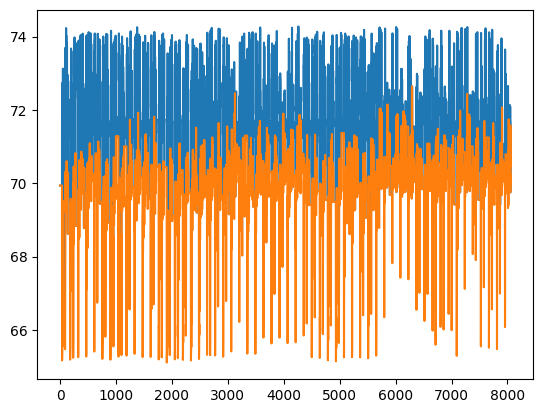

In [35]:
df['MAIN BOILER:Boiler Outlet Temperature [C](TimeStep)'].plot()
df['MAIN BOILER:Boiler Inlet Temperature [C](TimeStep)'].plot()

In [7]:

df = df.dropna(subset=['datetime'])
df['date'] = df['datetime'].dt.date

# group by day and sum
daily = df.groupby('date').agg({
    'MAIN BOILER:Boiler Heating Energy [J](TimeStep)': 'sum',
    'MAIN BOILER:Boiler NaturalGas Energy [J](TimeStep)': 'sum'
})

# daily efficiency
daily['efficiency'] = daily['MAIN BOILER:Boiler Heating Energy [J](TimeStep)'] / daily['MAIN BOILER:Boiler NaturalGas Energy [J](TimeStep)']

# daily mean and range for plotting (as in Beizaee)
daily_mean = daily['efficiency'].mean()
daily_min = daily['efficiency'].min()
daily_max = daily['efficiency'].max()


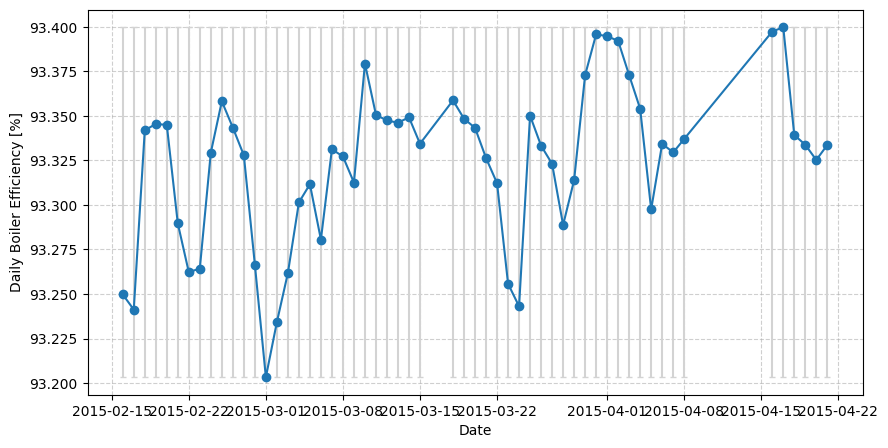

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.errorbar(daily.index, daily['efficiency']*100,
             yerr=[(daily['efficiency']-daily_min)*100, (daily_max-daily['efficiency'])*100],
             fmt='o-', ecolor='lightgrey', capsize=2)
plt.ylabel('Daily Boiler Efficiency [%]')
plt.xlabel('Date')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [10]:
(df['MAIN BOILER:Boiler Heating Energy [J](TimeStep)'].sum() / df['MAIN BOILER:Boiler NaturalGas Energy [J](TimeStep)'].sum())

np.float64(0.9331314529434758)

<Axes: >

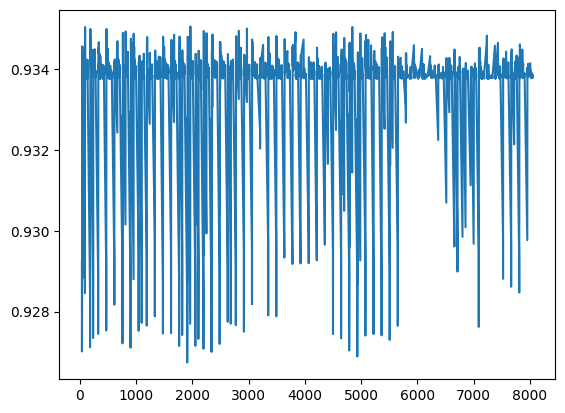

In [11]:
(df['MAIN BOILER:Boiler Heating Energy [J](TimeStep)'] / df['MAIN BOILER:Boiler NaturalGas Energy [J](TimeStep)']).dropna().plot()

In [12]:
(df['MAIN BOILER:Boiler Heating Energy [J](TimeStep)'] / df['MAIN BOILER:Boiler NaturalGas Energy [J](TimeStep)']).dropna().mean()

np.float64(0.9335594895063885)

<Axes: >

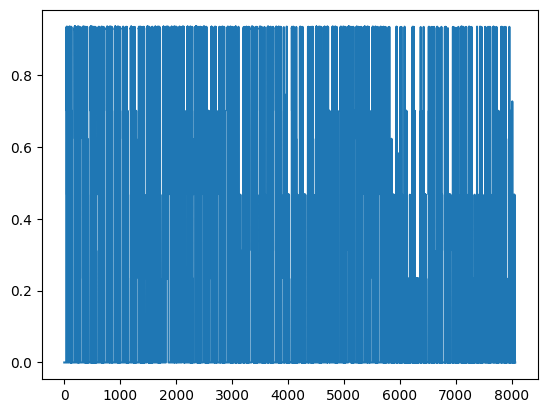

In [13]:
df['MAIN BOILER:Boiler Efficiency [](TimeStep)'].plot()

<Axes: >

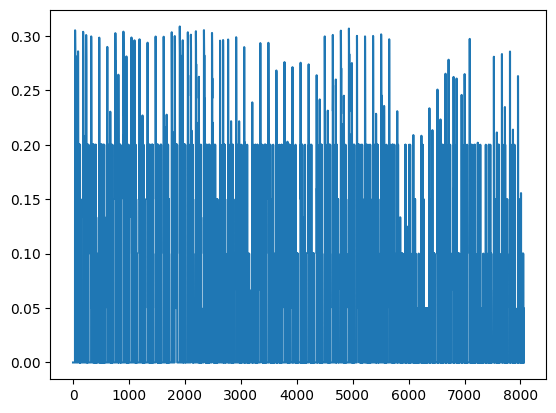

In [14]:
df['MAIN BOILER:Boiler Part Load Ratio [](TimeStep)'].plot()

In [15]:
import numpy as np

# grab just the AFN ACH columns
ach_cols = df.filter(like='AFN Zone Infiltration Air Change Rate').columns

# 1) plain time-average per zone (over the whole DataFrame)
ach_mean = df[ach_cols].mean(numeric_only=True)

# (optional) tidy the index to only the zone name before the ':'
ach_mean.index = ach_mean.index.str.split(':').str[0]

# sort and pretty print
print(ach_mean.sort_values(ascending=False).round(3))


SUBFLOOR           16.994
KITCHEN             1.120
BACKROOM            0.953
FRONT_ROOM          0.921
HALL_DOWNSTAIRS     0.767
BATHROOM            0.001
BEDROOM_3           0.001
BEDROOM_2           0.000
BEDROOM_1           0.000
LOFT                0.000
HALL_UPSTAIRS       0.000
dtype: float64


In [16]:
import pandas as pd

# --- Measured infiltration rates (ACH) for House 1 from Table 6-2 ---
measured_ach = {
    "FRONT_ROOM": 0.23,       # Living room
    "BACKROOM": 0.55,         # Dining room
    "KITCHEN": 1.65,
    "HALL_DOWNSTAIRS": 2.02,
    "HALL_UPSTAIRS": 0.02,
    "BEDROOM_1": 0.0,
    "BEDROOM_2": 0.0,
    "BEDROOM_3": 0.15,        # unoccupied room
    "BATHROOM": 0.02,
    "WC": 0.0,
    "SUBFLOOR": 21.0,
    "LOFT": 0.0               # roof infiltration
}

# --- Your modelled ACHs (already averaged with .mean) ---
modelled_ach = ach_mean.to_dict()  # from your snippet

# --- Merge into a DataFrame for comparison ---
df_compare = pd.DataFrame.from_dict(measured_ach, orient="index", columns=["Measured_ACH"])
df_compare["Modelled_ACH"] = df_compare.index.map(modelled_ach).fillna(0.0)

# Compute difference and percent error
df_compare["Difference"] = df_compare["Modelled_ACH"] - df_compare["Measured_ACH"]
df_compare["%Error"] = (df_compare["Difference"] / df_compare["Measured_ACH"].replace(0, pd.NA)) * 100

# Nice formatting
print(df_compare.round(3))


                 Measured_ACH  Modelled_ACH  Difference      %Error
FRONT_ROOM               0.23         0.921       0.691  300.634727
BACKROOM                 0.55         0.953       0.403   73.285911
KITCHEN                  1.65         1.120      -0.530  -32.144546
HALL_DOWNSTAIRS          2.02         0.767      -1.253   -62.01165
HALL_UPSTAIRS            0.02         0.000      -0.020  -99.004463
BEDROOM_1                0.00         0.000       0.000        <NA>
BEDROOM_2                0.00         0.000       0.000        <NA>
BEDROOM_3                0.15         0.001      -0.149   -99.54523
BATHROOM                 0.02         0.001      -0.019  -95.577646
WC                       0.00         0.000       0.000        <NA>
SUBFLOOR                21.00        16.994      -4.006  -19.074969
LOFT                     0.00         0.000       0.000        <NA>


In [17]:
def calculate_scaling_factors(measured: dict, modelled: dict, ignore=("SUBFLOOR",)) -> dict:
    """
    Calculate scaling factors = measured / modelled.
    Ignore zones with 0 measured or modelled values, and any in 'ignore'.
    """
    factors = {}
    ignore_upper = {i.upper() for i in ignore}
    for zone, meas in measured.items():
        mod = modelled.get(zone)
        if zone.upper() in ignore_upper:
            continue
        if meas > 0 and mod and mod > 0:
            factors[zone.lower()] = meas / mod
    return factors

# Example usage
scaling_factors = calculate_scaling_factors(measured_ach, modelled_ach)



In [18]:
scaling_factors

{'front_room': 0.2496039243109075,
 'backroom': 0.57708096221088,
 'kitchen': 1.4737208836051325,
 'hall_downstairs': 2.632386006758574,
 'hall_upstairs': 100.44832095104958,
 'bedroom_3': 219.89130127385022,
 'bathroom': 22.612390993938515}

In [19]:
def calculate_measured_ratios(measured: dict, ignore: tuple = ("SUBFLOOR",)) -> dict:
    """
    Calculate ratios of measured ACH relative to the average of all non-ignored zones.

    Args:
        measured: dict of {zone: measured_ach}
        ignore: zones to exclude (case-insensitive), e.g. SUBFLOOR

    Returns:
        dict of {zone: ratio}, where ratio = measured_ach / avg_measured
    """
    ignore_upper = {i.upper() for i in ignore}

    # filter out ignored and zero/negative values
    vals = [v for z, v in measured.items() if z.upper() not in ignore_upper and v > 0]
    if not vals:
        return {z: 1.0 for z in measured}  # fallback

    avg_val = sum(vals) / len(vals)
    ratios = {}
    for zone, val in measured.items():
        if zone.upper() in ignore_upper:
            ratios[zone] = None  # mark as ignored
        else:
            ratios[zone] = val / avg_val if avg_val > 0 else 1.0
    return ratios


def normalise_ratios(ratios: dict) -> dict:
    """
    Renormalise ratios so the smallest positive ratio becomes 1.0.
    Zeros and None are left as-is.
    """
    positives = [v for v in ratios.values() if v not in (None, 0) and v > 0]
    if not positives:
        return ratios

    min_val = min(positives)
    return {
        z: (v / min_val if v not in (None, 0) else v)
        for z, v in ratios.items()
    }


ratios = {
    "FRONT_ROOM": 0.3469,
    "BACKROOM": 0.8297,
    "KITCHEN": 2.4892,
    "HALL_DOWNSTAIRS": 3.0474,
    "HALL_UPSTAIRS": 0.03017,
    "BEDROOM_1": 0.0,
    "BEDROOM_2": 0.0,
    "BEDROOM_3": 0.2263,
    "BATHROOM": 0.03017,
    "WC": 0.0,
    "SUBFLOOR": None,
    "LOFT": 0.0
}

scaled = normalise_ratios(ratios)

for z, v in scaled.items():
    print(f"{z:15s}: {v}")


FRONT_ROOM     : 11.498176997016904
BACKROOM       : 27.50082863771959
KITCHEN        : 82.50580046403712
HALL_DOWNSTAIRS: 101.00762346702022
HALL_UPSTAIRS  : 1.0
BEDROOM_1      : 0.0
BEDROOM_2      : 0.0
BEDROOM_3      : 7.500828637719589
BATHROOM       : 1.0
WC             : 0.0
SUBFLOOR       : None
LOFT           : 0.0


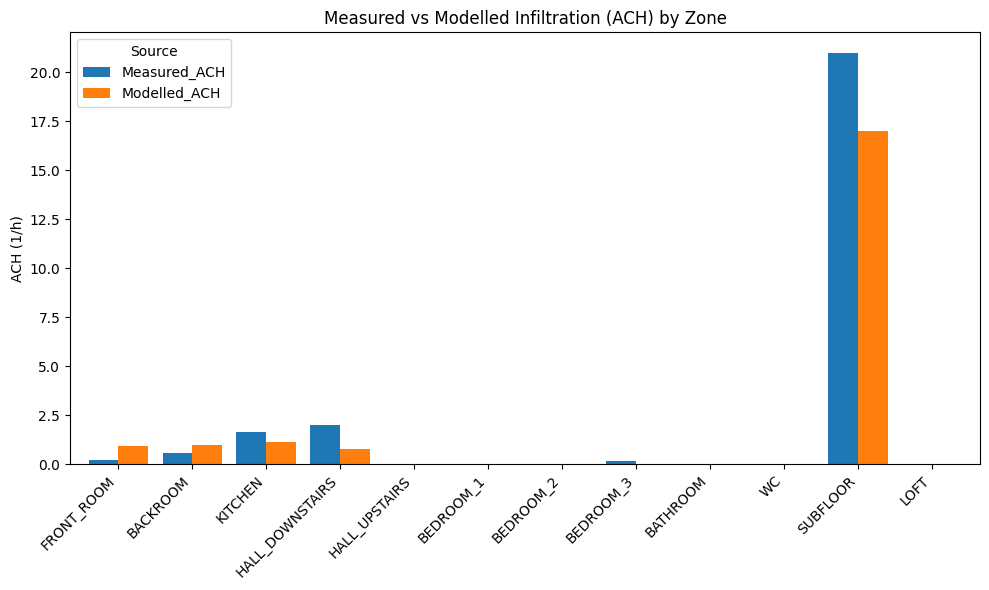

In [20]:
import matplotlib.pyplot as plt

# Bar plot of measured vs modelled ACH
ax = df_compare[["Measured_ACH", "Modelled_ACH"]].plot(
    kind="bar", figsize=(10,6), width=0.8
)

ax.set_ylabel("ACH (1/h)")
ax.set_title("Measured vs Modelled Infiltration (ACH) by Zone")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Source")
plt.tight_layout()
plt.show()


In [28]:

# Reconstructing Table 4-3 from Beizaee's thesis
beizaee_temp_data = {
    "Room": [
        "Living Room", "Dining Room", "Bedroom 1", "Bedroom 2", "Bathroom",
        "Unoccupied Room", "Circulation Areas", "Kitchen", "Whole House"
    ],
    # Each tuple = (ZC, CC)
    "WholeDay": [
        (19.2, 20.0),
        (18.2, 18.7),
        (18.0, 18.3),
        (17.2, 18.2),
        (16.5, 17.7),
        (14.8, 15.3),
        (19.1, 19.5),
        (19.6, 20.0),
        (18.1, 18.7),
    ],
    "HeatingOn": [
        (20.3, 21.5),
        (19.0, 19.5),
        (18.9, 19.2),
        (17.6, 19.1),
        (17.3, 18.9),
        (14.9, 15.5),
        (20.3, 20.8),
        (20.7, 21.2),
        (18.9, 19.7),
    ],
    "Occupied": [
        (22.3, 22.5),
        (20.4, 20.1),
        (18.9, 19.2),
        (16.3, 18.1),
        (19.7, 19.1),
        (None, None),
        (None, None),
        (23.0, 23.6),
        (19.7, 20.1),
    ],
    "Unoccupied": [
        (18.7, 20.5),
        (18.8, 19.4),
        (18.7, 19.4),
        (17.9, 19.3),
        (17.2, 18.9),
        (14.9, 15.5),
        (20.3, 20.8),
        (20.4, 20.8),
        (18.6, 19.6),
    ],
    "HeatingOff": [
        (18.0, 18.4),
        (17.4, 17.7),
        (17.1, 17.3),
        (16.5, 17.1),
        (15.5, 16.4),
        (14.6, 15.0),
        (17.8, 18.1),
        (18.4, 18.6),
        (17.1, 17.5),
    ]
}

# Convert to MultiIndex DataFrame
rows = []
for i, room in enumerate(beizaee_temp_data["Room"]):
    for period in ["WholeDay", "HeatingOn", "Occupied", "Unoccupied", "HeatingOff"]:
        zc, cc = beizaee_temp_data[period][i]
        if zc is not None and cc is not None:
            rows.append((room, period, "ZC", zc))
            rows.append((room, period, "CC", cc))

beizaee_full_df = pd.DataFrame(rows, columns=["Room", "Period", "Control", "Temp"])
beizaee_full_df = beizaee_full_df.pivot_table(index=["Room", "Period"], columns="Control", values="Temp").reset_index()

# Optional: easier plotting
beizaee_pivot = beizaee_full_df.pivot(index="Room", columns="Period")


# Beizaee Table 6 reference values
beizaee_data = {
    "Room": [
        "Living Room", "Dining Room", "Bedroom 1", "Bedroom 2", "Bathroom",
        "Unoccupied Room", "Circulation Areas", "Kitchen", "Whole House"
    ],
    "CC": [20.0, 18.7, 18.3, 18.2, 17.7, 15.3, 19.5, 20.0, 18.7],
    "ZC": [19.2, 18.2, 18.0, 17.2, 16.5, 14.8, 19.1, 19.6, 18.1],
}

beizaee_df = pd.DataFrame(beizaee_data).set_index("Room")

# Room name mapping between model and Beizaee paper
room_mapping = {
    'FRONT_ROOM': 'Living Room',
    'BACKROOM': 'Dining Room',
    'BEDROOM_1': 'Bedroom 1',
    'BEDROOM_2': 'Bedroom 2',
    'BEDROOM_3': 'Unoccupied Room',
    'BATHROOM': 'Bathroom',
    'KITCHEN': 'Kitchen',
    'HALL_DOWNSTAIRS': 'Circulation Areas',
    'HALL_UPSTAIRS': 'Circulation Areas',
}

def compare_room_temperatures(sim_data, room_mapping, baseboard_filter=None, floor_areas=None):
    """
    Compare room temperatures across simulations.
    'Whole House' temperature is computed as floor-area-weighted mean using Beizaee categories.
    """
    results = {}
    energy_use = {}

    if floor_areas is None:
        floor_areas = {
            "HALL_DOWNSTAIRS": 7.02,
            "FRONT_ROOM": 14.04,
            "KITCHEN": 11.34,
            "BACKROOM": 11.34,
            "BEDROOM_3": 6.86,
            "BEDROOM_1": 11.51,
            "HALL_UPSTAIRS": 4.00,
            "BATHROOM": 7.11,
            "BEDROOM_2": 12.39,
        }

    beizaee_floor_areas = get_floor_areas_by_beizaee_category(floor_areas, room_mapping)
    total_area = sum(beizaee_floor_areas.values())

    for label, df in sim_data.items():
        energy_use[label] = calculate_kwh_per_day(df["Gas"])

        df_filtered = df.copy()
        if baseboard_filter is not None and "Baseboard Availability" in df.columns:
            df_filtered = df[df["Baseboard Availability"] == baseboard_filter]

        df_filtered = clean_zone_columns(df_filtered, room_mapping)
        means = df_filtered[room_mapping.keys()].mean()
        means.index = means.index.map(room_mapping)
        grouped = means.groupby(level=0).mean()

        weighted_sum = 0.0
        for cat, area in beizaee_floor_areas.items():
            if cat in grouped.index:
                weighted_sum += grouped.loc[cat] * area
        grouped["Whole House"] = weighted_sum / total_area

        results[label] = grouped

    return pd.DataFrame(results).round(2), energy_use



def get_floor_areas_by_beizaee_category(floor_areas, room_mapping):
    """
    Aggregate zone-level floor areas into Beizaee room categories using room_mapping.
    Handles multiple zones mapping to the same category (e.g., circulation areas).
    """
    beizaee_floor_areas = {}
    for zone, area in floor_areas.items():
        category = room_mapping.get(zone, zone)
        beizaee_floor_areas[category] = beizaee_floor_areas.get(category, 0) + area
    return beizaee_floor_areas


beizaee_cockroft_deltas = {
    "Living room": {"Beizaee": 1.193, "Cockroft": 1.230},
    "Dining room": {"Beizaee": 0.496, "Cockroft": 0.733},
    "Kitchen": {"Beizaee": 0.496, "Cockroft": 0.348},
    "Circulation areas": {"Beizaee": 0.496, "Cockroft": 0.141},
    "Bedroom 2": {"Beizaee": 1.496, "Cockroft": 0.822},
    "Unoccupied Room": {"Beizaee": 0.600, "Cockroft": 0.289},
    "Bedroom 1": {"Beizaee": 0.296, "Cockroft": 0.363},
    "Bathroom": {"Beizaee": 1.593, "Cockroft": 1.807},
    "Whole House": {"Beizaee": 0.800, "Cockroft": 0.667}
}

# Normalise keys for consistency
beizaee_cockroft_deltas_normalised = {
    k.title(): {
        "Beizaee": -v["Beizaee"],
        "Cockroft": -v["Cockroft"]
    }
    for k, v in beizaee_cockroft_deltas.items()
}


def load_simulation_results(base_path, experiment_path, run, timesteps_per_hour=6):
    from pathlib import Path
    # run_dir = Path(base_path) / "runs" / run
    run_dir = Path(base_path) / experiment_path / run
    combined_dfs = {}

    for exp_dir in run_dir.iterdir():
        if not exp_dir.is_dir():
            continue
        csv_path = exp_dir / "eplusout.csv"
        if not csv_path.exists():
            continue

        try:
            df = pd.read_csv(csv_path)

            temp_cols = [col for col in df.columns if "Zone Air Temperature" in col]
            gas_cols = [col for col in df.columns if "Boiler NaturalGas" in col]
            baseboard_cols = [col for col in df.columns if "baseboard availability" in col.lower()]

            df_filtered = df[temp_cols + gas_cols + baseboard_cols].copy()
            df_filtered.columns = df_filtered.columns.str.replace(r" \\(TimeStep\\)", "", regex=True)

            # Time index
            index = pd.date_range("2000-01-01", periods=len(df_filtered), freq=f"{60 // timesteps_per_hour}min")
            df_filtered.index = index
            combined_dfs[exp_dir.name] = df_filtered

        except Exception as e:
            print(f"⚠️ Skipping {exp_dir.name}: {e}")

    return combined_dfs

def clean_zone_columns(df, room_mapping):
    rename_map = {}
    for col in df.columns:
        for zone in room_mapping:
            if zone in col and "Temperature" in col:
                rename_map[col] = zone
        if "Gas" in col:
            rename_map[col] = "Gas"
        if "baseboard availability" in col.lower():
            rename_map[col] = "Baseboard Availability"
    return df.rename(columns=rename_map)

def calculate_kwh_per_day(gas_series, timesteps_per_hour=6):
    total_mj = gas_series.sum() / 1e6
    total_days = len(gas_series) / (timesteps_per_hour * 24)
    return (total_mj * 0.277777778) / total_days



def load_all_run_results(base_path, experiment_path, run, room_mapping, timesteps_per_hour=6, controls=None):
    """
    Loads and cleans all simulation results for a single run period (e.g., 'beizaee', 'lynch').

    Args:
        controls: Optional list of control types to include (e.g., ['conventional_control', 'zonal_control'])
    Returns:
        dict of cleaned DataFrames {experiment_name: df}
    """
    raw_results = load_simulation_results(base_path, experiment_path, run, timesteps_per_hour)
    cleaned = {}
    for name, df in raw_results.items():
        if controls:
            if not any(name.startswith(c) for c in controls):
                continue  # skip if not in the allowed control types
        cleaned[name] = clean_zone_columns(df, room_mapping)
    return cleaned



def plot_temp_differences_with_beizaee(df_compare, beizaee_df, run_label):
    beizaee_delta = (beizaee_df["ZC"] - beizaee_df["CC"]).dropna()
    delta_zonal = df_compare.get("zonal_control") - df_compare.get("conventional_control")
    delta_occ = df_compare.get("occupancy_control") - df_compare.get("conventional_control")

    rooms = beizaee_delta.index.intersection(delta_zonal.index).intersection(delta_occ.index)
    x = np.arange(len(rooms))

    fig, ax = plt.subplots(figsize=(12, 6))
    width = 0.35

    ax.bar(x - width/2, delta_zonal.loc[rooms], width, label="Conv - Zonal (Sim)", color="tab:blue")
    ax.bar(x + width/2, delta_occ.loc[rooms], width, label="Conv - Occupancy (Sim)", color="tab:orange")
    ax.scatter(x - width/2, beizaee_delta.loc[rooms], color='black', label='Conv - Zonal (Beizaee)', zorder=5)

    for i, val in enumerate(beizaee_delta.loc[rooms]):
        ax.text(x[i] - width/2, val + 0.1, f"{val:.1f}°C", ha='center', va='bottom', fontsize=9)

    ax.axhline(0, color="grey", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(rooms, rotation=45, ha='right')
    ax.set_ylabel("ΔT (Conventional - Smart Control) [°C]")
    ax.set_title(f"Room Temp Difference Compared to Conventional ({run_label})")
    ax.legend()
    plt.tight_layout()
    plt.show()

def compare_room_temperatures(sim_data, room_mapping, baseboard_filter=None):
    """
    Compare room temperatures across simulations.

    Args:
        sim_data (dict): Dictionary of simulation dataframes.
        room_mapping (dict): Mapping from dataframe columns to room names.
        baseboard_filter (int or None):
            - 1 to filter where Baseboard is ON
            - 0 to filter where Baseboard is OFF
            - None for no filtering on Baseboard Availability

    Returns:
        (DataFrame, dict): Temperature results and energy use dictionary.
    """

    results = {}
    energy_use = {}

    for label, df in sim_data.items():
        # Always calculate energy from full dataset
        energy_use[label] = calculate_kwh_per_day(df["Gas"])

        # Optionally filter for baseboard conditions
        df_filtered = df.copy()
        if baseboard_filter is not None and "Baseboard Availability" in df.columns:
            df_filtered = df[df["Baseboard Availability"] == baseboard_filter]

        df_filtered = clean_zone_columns(df_filtered, room_mapping)
        means = df_filtered[room_mapping.keys()].mean()
        means.index = means.index.map(room_mapping)
        grouped = means.groupby(level=0).mean()
        grouped["Whole House"] = grouped.mean()

        results[label] = grouped

    return pd.DataFrame(results).round(2), energy_use



def plot_boiler_config_comparison(results_dict, config_tag, room_mapping, beizaee_df=None,
                                   beizaee_cockroft_deltas=None, run_label=None, controls=None,
                                   floor_areas=None):
    """
    Plots temperature differences between selected smart control(s) and conventional control.
    'Whole House' value is computed as floor-area-weighted mean aggregated by Beizaee room categories.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    # === Extract relevant runs ===
    filtered = {k: v for k, v in results_dict.items() if config_tag in k}
    if not filtered:
        print(f"⚠️ Warning: No configurations found for {config_tag}.")
        return

    # === Compute temperature means during baseboard heating ===
    df_compare, _ = compare_room_temperatures(filtered, room_mapping, baseboard_filter=1)
    df_compare.columns = [col.split('__')[0] for col in df_compare.columns]

    # === Controls ===
    if controls is None:
        controls = ["zonal_control", "occupancy_control"]
    if "conventional_control" not in controls:
        controls = ["conventional_control"] + controls

    for control in controls:
        if control not in df_compare.columns:
            df_compare[control] = pd.Series([0] * len(df_compare), index=df_compare.index)

    # === Floor areas by zone ===
    if floor_areas is None:
        floor_areas = {
            "HALL_DOWNSTAIRS": 7.02,
            "FRONT_ROOM": 14.04,
            "KITCHEN": 11.34,
            "BACKROOM": 11.34,
            "BEDROOM_3": 6.86,
            "BEDROOM_1": 11.51,
            "HALL_UPSTAIRS": 4.00,
            "BATHROOM": 7.11,
            "BEDROOM_2": 12.39,
        }

    # === Aggregate floor areas by Beizaee room categories ===
    beizaee_floor_areas = {}
    for zone, area in floor_areas.items():
        cat = room_mapping.get(zone, zone)
        beizaee_floor_areas[cat] = beizaee_floor_areas.get(cat, 0) + area

    total_area = sum(beizaee_floor_areas.values())

    # === Recompute 'Whole House' weighted average for each control ===
    for control in controls:
        weighted_sum = 0.0
        for cat, area in beizaee_floor_areas.items():
            if cat in df_compare.index:
                weighted_sum += df_compare.loc[cat, control] * area
        whole_house_val = weighted_sum / total_area
        if "Whole House" not in df_compare.index:
            df_compare.loc["Whole House"] = 0
        df_compare.loc["Whole House", control] = whole_house_val

    # === Compute deltas ===
    delta_dict = {
        ctrl: df_compare[ctrl] - df_compare["conventional_control"]
        for ctrl in controls if ctrl != "conventional_control"
    }

    # === Sort zones ===
    first_delta = next(iter(delta_dict.values()))
    sort_order = first_delta.drop("Whole House", errors="ignore").sort_values().index.tolist()
    if "Whole House" in first_delta:
        sort_order.append("Whole House")

    x = np.arange(len(sort_order))
    width = 0.25
    fig, ax = plt.subplots(figsize=(12, 6))

    offsets = {"zonal_control": -width / 2, "occupancy_control": width / 2}
    colors = {"zonal_control": "tab:blue", "occupancy_control": "tab:orange"}
    labels = {"zonal_control": "Zonal - Conv", "occupancy_control": "Occupancy - Conv"}

    for control in delta_dict:
        delta = delta_dict[control]
        ax.bar(x + offsets[control], delta.loc[sort_order], width=width,
               label=f"{labels[control]} (Simulated)", color=colors[control])

    # === Overlay Beizaee & Cockroft ===
    if beizaee_cockroft_deltas:
        for label, color, marker in [("Beizaee", "black", "o"), ("Cockroft", "darkgreen", "s")]:
            values = {k: v[label] for k, v in beizaee_cockroft_deltas.items() if k in sort_order}
            idxs = [i for i, room in enumerate(sort_order) if room in values]
            y_vals = [values[room] for room in sort_order if room in values]
            ax.scatter([x[i] for i in idxs], y_vals, color=color, marker=marker, label=f"Conv - Zonal ({label})")
            for i, val in zip(idxs, y_vals):
                ax.text(x[i], val + 0.1, f"{val:.1f}°C", ha='center', va='bottom', fontsize=9)

    ax.axhline(0, color="grey", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(sort_order, rotation=45, ha='right')
    ax.set_ylabel("ΔT (Conventional - Zonal Control) [°C]")
    ax.legend(title="Control Type", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
    plt.tight_layout()
    plt.show()





def plot_gas_consumption_by_config(results_dict,
                                   base_title="Gas Use and Relative Savings by Control & Boiler Config",
                                   controls=None,
                                   show_references=True):
    """
    Plots:
    - Absolute daily gas use (kWh/day)
    - Relative % reduction vs conventional
    Optional: overlay Beizaee and Cockroft reference values.
    """
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np

    def calculate_kwh_per_day(gas_series, timesteps_per_hour=6):
        total_mj = gas_series.sum() / 1e6
        total_days = len(gas_series) / (timesteps_per_hour * 24)
        return (total_mj * 0.277777778) / total_days

    # === Colour config ===
    control_colours = {
        "Conventional": "grey",
        "Zonal": "lightblue",
        "Occupancy": "purple"
    }

    # === Reference values ===
    ref_points = {
        "Beizaee": {"Conventional": 62.4, "Zonal": 53.6},
        "Cockroft": {"Conventional": 62.6, "Zonal": 55.2},
    }
    highlight_config = "Part-load: 0_2 Eff. Curve: quadratic"

    # === Build DataFrame of daily energy use ===
    energy_data = {}
    for name, df in results_dict.items():
        control = name.split("__")[0]
        if controls and control not in controls:
            continue
        part = name.split("__part_")[1].split("__")[0]
        eff = name.split("__eff_")[1]
        config = f"Part-load: {part} Eff. Curve: {eff}"
        kwh = calculate_kwh_per_day(df["Gas"])
        if config not in energy_data:
            energy_data[config] = {}
        energy_data[config][control] = kwh

    df_energy = pd.DataFrame(energy_data).T.sort_index()
    df_energy = df_energy[[c for c in ["conventional_control", "zonal_control", "occupancy_control"] if c in df_energy.columns]]
    df_energy.columns = [c.replace("_control", "").capitalize() for c in df_energy.columns]

    # === Sort the configurations (custom order) ===
    # custom_order = [
    #     "Part-load: 0_4 Eff. Curve: quadratic",
    #     "Part-load: 0_2 Eff. Curve: quadratic",
    #     "Part-load: 0_0 Eff. Curve: quadratic",
    #     "Part-load: 0_4 Eff. Curve: constant",
    #     "Part-load: 0_2 Eff. Curve: constant",
    #     "Part-load: 0_0 Eff. Curve: constant",
    #     "Part-load: 0_4 Eff. Curve: cubic",
    #     "Part-load: 0_2 Eff. Curve: cubic",
    #     "Part-load: 0_0 Eff. Curve: cubic",
    # ]

    custom_order = [
        #"Part-load: 0_4 Eff. Curve: quadratic",
        "Part-load: 0_2 Eff. Curve: quadratic",
        #"Part-load: 0_0 Eff. Curve: quadratic",
        #"Part-load: 0_4 Eff. Curve: constant",
        #"Part-load: 0_2 Eff. Curve: constant",
        #"Part-load: 0_0 Eff. Curve: constant",
        #"Part-load: 0_4 Eff. Curve: cubic",
        #"Part-load: 0_2 Eff. Curve: cubic",
        #"Part-load: 0_0 Eff. Curve: cubic",
    ]
    df_energy = df_energy.loc[custom_order]

    # === Calculate relative savings ===
    if "Conventional" in df_energy.columns:
        baseline = df_energy["Conventional"]
        df_relative = (1 - df_energy.divide(baseline, axis=0)) * 100
    else:
        df_relative = None

    # === Plot ===
    fig, axes = plt.subplots(nrows=2, figsize=(12, 10), sharex=True, gridspec_kw={"height_ratios": [1, 1]})

    # Absolute gas use
    control_order = ["Conventional", "Zonal", "Occupancy"]
    available_controls = [c for c in control_order if c in df_energy.columns]
    df_energy[available_controls].plot(kind="bar", ax=axes[0],
                                       color=[control_colours[c] for c in available_controls])
    axes[0].set_ylabel("Daily Gas Use (kWh/day)")
    axes[0].set_title("Absolute Gas Consumption")
    axes[0].legend(title="Control Type", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
    axes[0].grid(axis="y", linestyle="--", alpha=0.3)

    # Reference dots (optional)
    if show_references:
        for i, config in enumerate(df_energy.index):
            if config != highlight_config:
                continue
            axes[0].scatter(i - 0.1, ref_points["Beizaee"]["Conventional"], color="black", marker="o", label="Beizaee — Conv", s=100)
            axes[0].scatter(i + 0.1, ref_points["Beizaee"]["Zonal"], facecolors='none', edgecolors='black', marker="o", label="Beizaee — Zonal", s=100)
            axes[0].scatter(i - 0.1, ref_points["Cockroft"]["Conventional"], color="grey", marker="o", label="Cockroft — Conv", s=100)
            axes[0].scatter(i + 0.1, ref_points["Cockroft"]["Zonal"], facecolors='none', edgecolors='grey', marker="o", label="Cockroft — Zonal", s=100)

    # Relative savings
    if df_relative is not None:
        rel_controls = [c for c in control_order if c in df_relative.columns and c != "Conventional"]
        df_relative_subset = df_relative[rel_controls]
        df_relative_subset.plot(kind="bar", ax=axes[1],
                                color=[control_colours[c] for c in df_relative_subset.columns])
        axes[1].axhline(0, color="grey", linewidth=1)
        axes[1].set_ylabel("Relative Saving vs Conventional (%)")
        axes[1].set_title("Relative Energy Reduction")
        axes[1].grid(axis="y", linestyle="--", alpha=0.3)
        axes[1].get_legend().set_visible(False)

        if show_references:
            for i, config in enumerate(df_relative.index):
                if config != highlight_config:
                    continue
                rel_b = (1 - ref_points["Beizaee"]["Zonal"] / ref_points["Beizaee"]["Conventional"]) * 100
                rel_c = (1 - ref_points["Cockroft"]["Zonal"] / ref_points["Cockroft"]["Conventional"]) * 100
                axes[1].scatter(i, rel_b, facecolors='none', edgecolors='black', marker='o', label="Beizaee ΔT", s=100)
                axes[1].scatter(i, rel_c, facecolors='none', edgecolors='grey', marker='o', label="Cockroft ΔT", s=100)

    # X-axis labels
    labels = [f"Part-load: {config.split(' ')[1].replace('_', '.')}" for config in df_energy.index]
    axes[1].set_xticklabels(labels, rotation=0)

    # Efficiency labels between bars
    eff_labels, x_coords = [], []
    for i, config in enumerate(df_energy.index):
        if i % 2 == 0:
            if "quadratic" in config:
                eff_labels.append("Curve: quadratic")
            elif "constant" in config:
                eff_labels.append("Curve: constant")
            else:
                eff_labels.append("Curve: cubic")
            x_coords.append(i + 0.5)
    for i, label in zip(x_coords, eff_labels):
        axes[1].text(i, -2, label, ha='center', va='top', fontsize=10, color='black')

    fig.suptitle(base_title, fontsize=14)

    # Deduplicated legend
    handles, labels = axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    axes[0].legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 0.3), loc='upper left', frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

    return df_energy.round(2)



def plot_daily_gas_consumption(results_dict, room_mapping, controls=None, config_tag=None):
    """
    Plots daily gas consumption over the total simulation days for the selected boiler configuration
    and control types, showing only every 5th day on the x-axis.
    """
    def calculate_daily_consumption(gas_series, timesteps_per_hour=6):
        """
        Aggregates gas consumption by day from the hourly data and converts from J to kWh.
        """
        daily_gas_joules = gas_series.resample('D').sum()
        daily_gas_kwh = daily_gas_joules / 3.6e6
        return daily_gas_kwh

    # Friendly display names for legend labels
    control_labels = {
        "conventional_control": "Conventional",
        "zonal_control": "Zonal",
        "occupancy_control": "Occupancy"
    }

    # Prepare daily gas consumption data
    daily_consumption_data = {}

    # Filter results by config_tag (boiler configuration)
    if config_tag:
        filtered_results = {k: v for k, v in results_dict.items() if config_tag in k}
    else:
        filtered_results = results_dict

    for name, df in filtered_results.items():
        control = name.split("__")[0]

        if controls and control not in controls:
            continue

        daily_gas = calculate_daily_consumption(df["Gas"])

        if control not in daily_consumption_data:
            daily_consumption_data[control] = []
        daily_consumption_data[control].append(daily_gas)

    reindexed_data = {
        control: pd.concat(daily_data).reset_index(drop=True)
        for control, daily_data in daily_consumption_data.items()
    }

    fig, ax = plt.subplots(figsize=(12, 6))

    legend_order = ["conventional_control", "zonal_control", "occupancy_control"]

    for control in legend_order:
        if control in reindexed_data:
            daily_data = reindexed_data[control]
            x_ticks = np.arange(len(daily_data))
            ax.plot(
                x_ticks,
                daily_data.values,
                label=control_labels.get(control, control),  # Cleaned-up label
                marker="o"
            )

    x_ticks = np.arange(0, len(daily_data), 5)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f"Day {i+1}" for i in x_ticks])

    ax.set_xlabel("Simulation Day")
    ax.set_ylabel("Gas Consumption (kWh/day)")
    ax.legend(title="Control Type", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()



def plot_absolute_temperatures_with_beizaee_period(results_dict, config_tag, room_mapping, beizaee_full_df,
                                                   period="HeatingOn",
                                                   controls=["conventional_control", "zonal_control"],
                                                   baseboard_only=None, run_label=None,
                                                   floor_areas=None):
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np

    # === Extract matching runs ===
    filtered = {k: v for k, v in results_dict.items() if config_tag in k}
    if not filtered:
        print(f"⚠️ Warning: No configurations found for {config_tag}")
        return

    # === Compute room temps ===
    df_compare, _ = compare_room_temperatures(filtered, room_mapping, baseboard_filter=baseboard_only)
    df_compare.columns = [col.split('__')[0] for col in df_compare.columns]

    # === Floor areas ===
    if floor_areas is None:
        floor_areas = {
            "HALL_DOWNSTAIRS": 7.02,
            "FRONT_ROOM": 14.04,
            "KITCHEN": 11.34,
            "BACKROOM": 11.34,
            "BEDROOM_3": 6.86,
            "BEDROOM_1": 11.51,
            "HALL_UPSTAIRS": 4.00,
            "BATHROOM": 7.11,
            "BEDROOM_2": 12.39,
        }

    # Aggregate floor areas by Beizaee room category
    beizaee_floor_areas = {}
    for zone, area in floor_areas.items():
        cat = room_mapping.get(zone, zone)
        beizaee_floor_areas[cat] = beizaee_floor_areas.get(cat, 0) + area
    total_area = sum(beizaee_floor_areas.values())

    # === Recompute Whole House weighted averages ===
    for control in controls:
        weighted_sum = 0.0
        for cat, area in beizaee_floor_areas.items():
            if cat in df_compare.index:
                weighted_sum += df_compare.loc[cat, control] * area
        whole_house_val = weighted_sum / total_area
        if "Whole House" not in df_compare.index:
            df_compare.loc["Whole House"] = 0
        df_compare.loc["Whole House", control] = whole_house_val

    # === Prepare plotting dataframe ===
    df_plot = df_compare[controls].copy()

    # Add Beizaee reference values
    period_df = beizaee_full_df[beizaee_full_df["Period"] == period].set_index("Room")
    for control in controls:
        label = "CC" if control == "conventional_control" else "ZC"
        df_plot[f"Beizaee_{control}"] = period_df[label]

    # Ensure Whole House is last row
    if "Whole House" in df_plot.index:
        ordered_idx = [idx for idx in df_plot.index if idx != "Whole House"] + ["Whole House"]
        df_plot = df_plot.loc[ordered_idx]

    # === Plot ===
    fig, ax = plt.subplots(figsize=(13, 6))
    x = np.arange(len(df_plot.index))
    width = 0.3

    for i, control in enumerate(controls):
        bar_pos = x + i * width - width / 2
        ax.bar(bar_pos, df_plot[control], width=width, label=f"{control.replace('_control', '').capitalize()} (Sim)", color=f"C{i}")

        # Overlay Beizaee reference
        ax.scatter(bar_pos, df_plot[f"Beizaee_{control}"], color="black", marker="o", label=f"{control.replace('_control', '').capitalize()} (Beizaee)", zorder=5)

        # Label points
        for xi, temp in zip(bar_pos, df_plot[f"Beizaee_{control}"]):
            if pd.notna(temp):
                ax.text(xi, temp + 0.1, f"{temp:.1f}", ha='center', va='bottom', fontsize=8, color="black")

    ax.set_xticks(x)
    ax.set_xticklabels(df_plot.index, rotation=45, ha="right")
    ax.set_ylabel("Average Room Temperature [°C]")
    ax.set_title(f"Absolute Temps — {period} — {config_tag.replace('__', ' + ')}" + (f" — {run_label}" if run_label else ""))
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()



def plot_simulation_day(sim_data, day="Day 2", variable="temp", rooms=None, experiments=None):
    """
    Plot one day's worth of data from multiple experiments.

    Arguments:
        sim_data: dict of {experiment_name: DataFrame with zone temps + Gas}
        day: e.g. "Day 2" (logical day)
        variable: "temp" or "gas"
        rooms: list of rooms to include (only for temp)
        experiments: subset of sim_data keys to plot (defaults to all)
    """
    if experiments is None:
        experiments = list(sim_data.keys())

    if variable == "temp":
        if rooms is None:
            rooms = [
                "BACKROOM", "FRONT_ROOM", "KITCHEN", "HALL_DOWNSTAIRS", "HALL_UPSTAIRS",
                "BEDROOM_3", "BATHROOM", "BEDROOM_1", "BEDROOM_2"
            ]

        nrows = len(rooms)
        ncols = len(experiments)
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 3.5 * nrows), sharex=True, sharey=True)

        # Ensure axes is 2D array
        if nrows == 1 and ncols == 1:
            axes = [[axes]]
        elif nrows == 1:
            axes = [axes]
        elif ncols == 1:
            axes = [[ax] for ax in axes]

        for i, room in enumerate(rooms):
            for j, exp in enumerate(experiments):
                ax = axes[i][j]
                df = sim_data[exp]
                # Filter by day
                day_df = df[df.index.floor("D") == df.index.floor("D").unique()[int(day.split(" ")[1]) - 1]]
                day_df[room].plot(ax=ax, label="Air Temp", linestyle="-")

                ax.set_ylim(10, 25)
                ax.set_ylabel("Temp (°C)")
                ax.set_title(f"{room} – {exp.replace('_', ' ').title()}", fontsize=10)
                ax.grid(True)

                if i == nrows - 1:
                    ax.set_xlabel("Time")

                if i == 0 and j == ncols - 1:
                    ax.legend(loc="upper right")

        plt.tight_layout()
        plt.subplots_adjust(top=0.95)
        plt.show()

    elif variable == "gas":
        fig, ax = plt.subplots(figsize=(8, 4))
        for exp in experiments:
            df = sim_data[exp]
            day_df = df[df.index.floor("D") == df.index.floor("D").unique()[int(day.split(" ")[1]) - 1]]
            day_df["Gas"].plot(ax=ax, label=exp.replace("_", " ").title())

        ax.set_ylabel("Gas Consumption (MJ)")
        ax.set_title(f"Gas Use – {day}")
        ax.grid(True)
        ax.legend()
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("Invalid variable. Choose 'temp' or 'gas'.")



In [29]:
# Constants
RUN_DIR = "/workspaces/CUBES/beizaee_validation"
RUN = "beizaee" # "beizaee"  # or "lynch"
EXPERIMENT = "runs_h28_test_validation" # "runs" or "runs_h28_model_afn_validation" or "runs_h28_model_afn_evaluation"
BOILER_CONFIG = "part_0_2__eff_quadratic"  # You can specify any config tag here

# Load + clean
results = load_all_run_results(RUN_DIR, EXPERIMENT, RUN, room_mapping, controls=["conventional_control", "zonal_control", "occupancy_control"])



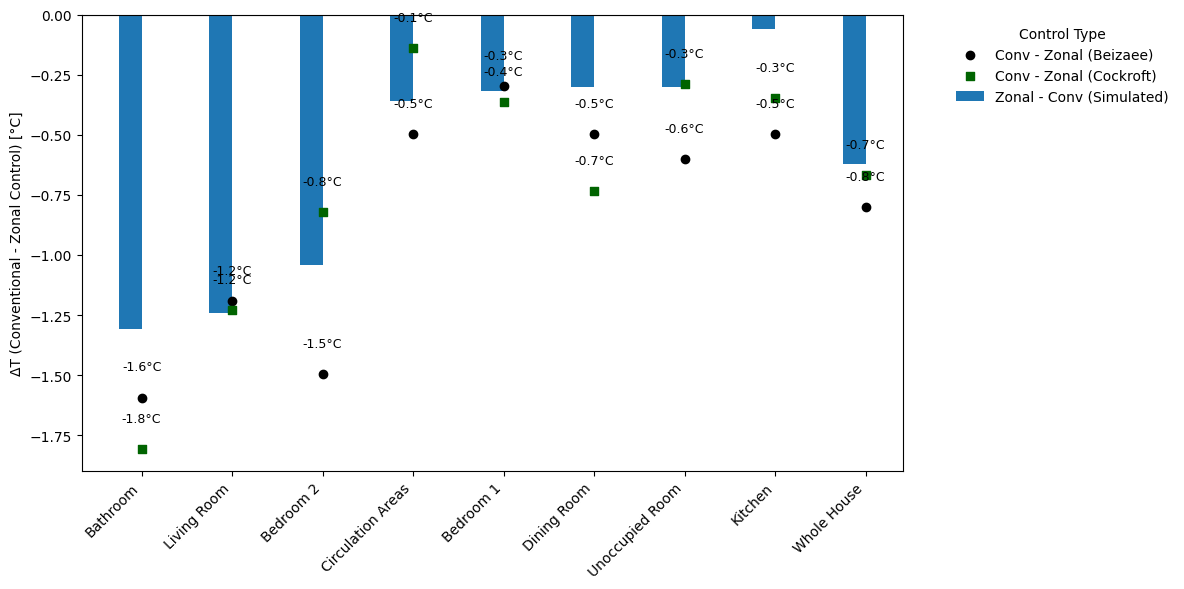

In [30]:

# Plot comparison with only conventional and zonal controls
plot_boiler_config_comparison(
    results_dict=results,
    config_tag=BOILER_CONFIG,  # Specify config tag here
    room_mapping=room_mapping,
    beizaee_cockroft_deltas=beizaee_cockroft_deltas_normalised,
    controls=["conventional_control", "zonal_control"]#, "occupancy_control"]
)



In [31]:
results['zonal_control__part_0_2__eff_quadratic']

,HALL_DOWNSTAIRS,FRONT_ROOM,KITCHEN,BACKROOM,BEDROOM_3,BEDROOM_1,HALL_UPSTAIRS,BATHROOM,BEDROOM_2,SUBFLOOR:Zone Air Temperature [C](TimeStep),LOFT:Zone Air Temperature [C](TimeStep),Gas,Baseboard Availability
2000-01-01 00:00:00,17.420824,17.522669,16.911060,16.338380,15.057178,17.911827,17.021328,15.135839,16.542767,11.775048,8.124943,0.0,0.0
2000-01-01 00:10:00,17.288953,17.371716,16.783407,16.229243,15.031501,17.828112,16.949351,15.091291,16.525597,11.714138,8.091018,0.0,0.0
2000-01-01 00:20:00,17.158164,17.220910,16.656849,16.119723,15.007809,17.746663,16.870780,15.049623,16.501055,11.632174,8.069784,0.0,0.0
2000-01-01 00:30:00,17.029573,17.073759,16.533994,16.012483,14.984053,17.667307,16.788695,15.008634,16.471786,11.572402,8.052510,0.0,0.0
2000-01-01 00:40:00,16.908699,16.937427,16.420509,15.913729,14.958215,17.590538,16.703964,14.966098,16.439216,11.558614,8.031719,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2000-02-25 23:10:00,20.580084,20.833850,20.162975,19.638355,19.273196,21.547397,19.961910,18.836016,19.427274,17.475931,15.650807,0.0,0.0
2000-02-25 23:20:00,20.506743,20.714545,20.070852,19.580899,19.265441,21.477194,19.902615,18.813206,19.405058,17.480014,15.577240,0.0,0.0
2000-02-25 23:30:00,20.417293,20.616846,20.009777,19.517635,19.255995,21.413696,19.868424,18.789927,19.374935,17.478734,15.507478,0.0,0.0
2000-02-25 23:40:00,20.357119,20.529154,19.941558,19.470649,19.245313,21.355582,19.822779,18.766081,19.350527,17.478538,15.440573,0.0,0.0


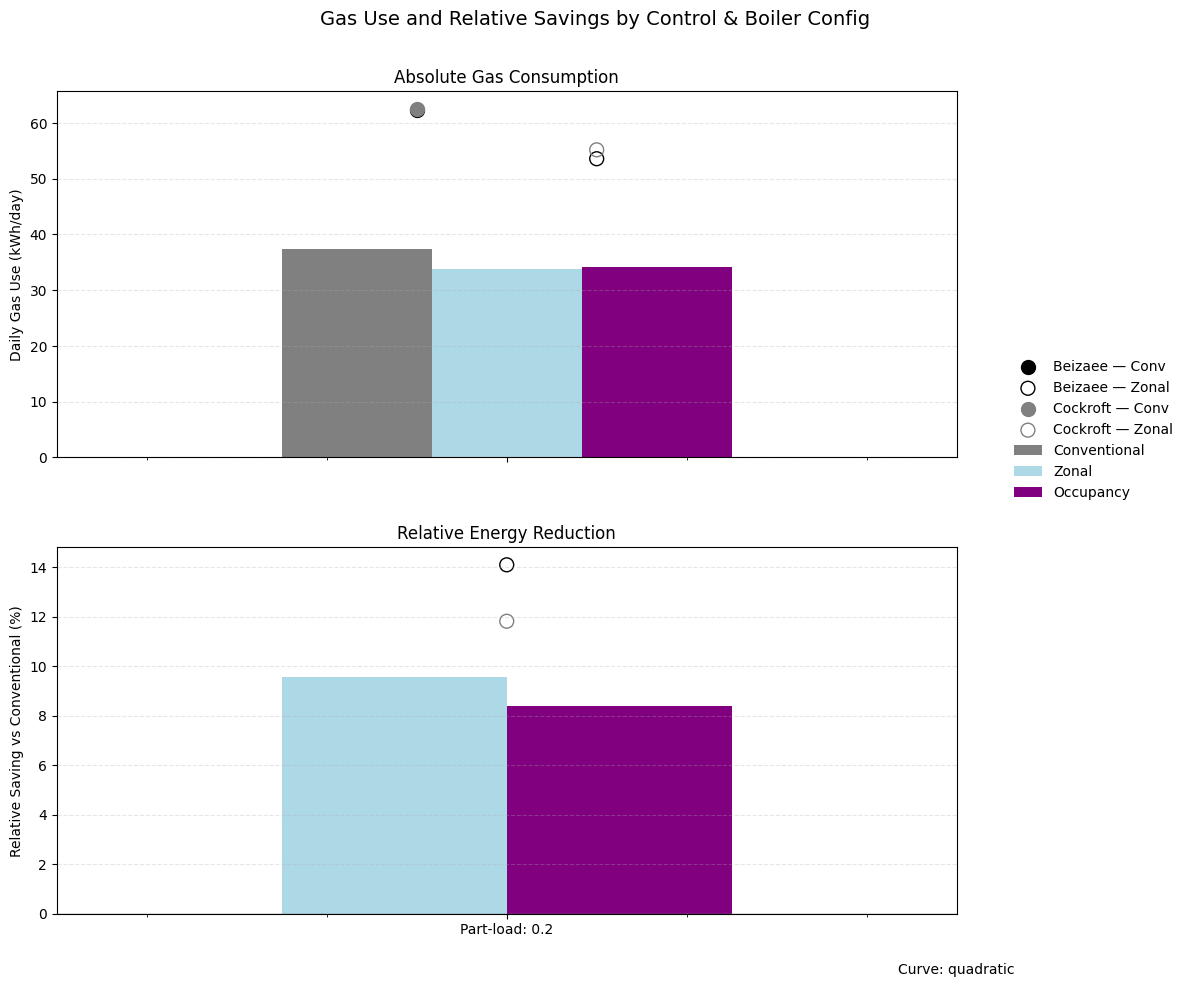

,Conventional,Zonal,Occupancy
Part-load: 0_2 Eff. Curve: quadratic,37.35,33.77,34.23


In [32]:
plot_gas_consumption_by_config(
    results,
    controls=["conventional_control", "zonal_control", "occupancy_control"],
    show_references=True)


In [ ]:
plot_absolute_temperatures_with_beizaee_period(
    results_dict=results,
    config_tag=BOILER_CONFIG,
    room_mapping=room_mapping,
    beizaee_full_df=beizaee_full_df,
    baseboard_only=None,
    period="WholeDay",  # or "WholeDay", "Occupied", etc.
    controls=["conventional_control", "zonal_control"],
    run_label="Model Validation"
)


In [ ]:
plot_absolute_temperatures_with_beizaee_period(
    results_dict=results,
    config_tag=BOILER_CONFIG,
    room_mapping=room_mapping,
    beizaee_full_df=beizaee_full_df,
    baseboard_only=1,
    period="HeatingOn",  # "HeatingOn", or "WholeDay", "Occupied", "Unoccupied", "HeatingOff" etc.
    controls=["conventional_control", "zonal_control"],
    run_label="Model Validation"
)


In [ ]:
plot_absolute_temperatures_with_beizaee_period(
    results_dict=results,
    config_tag=BOILER_CONFIG,
    room_mapping=room_mapping,
    beizaee_full_df=beizaee_full_df,
    baseboard_only=0,
    period="HeatingOff",  # "HeatingOn", or "WholeDay", "Occupied", "Unoccupied", "HeatingOff" etc.
    controls=["conventional_control", "zonal_control"],
    run_label="Model Validation"
)


In [ ]:
# === CONFIGURATION ===
CONTROLS_TO_PLOT = ["conventional_control", "zonal_control", "occupancy_control"]  # Flexibly choose which controls to plot
DAY = "Day 16"
VARIABLE = "temp"

# === Filter and label setup ===
# Only include results with matching boiler config and control type
selected_experiments = {
    k: v for k, v in results.items()
    if BOILER_CONFIG in k and any(k.startswith(ctrl) for ctrl in CONTROLS_TO_PLOT)
}

# Optional: clean labels (can be passed later if we modify the plotting function)
label_map = {
    k: k.replace(f"__{BOILER_CONFIG}", "").replace("_control", "").capitalize()
    for k in selected_experiments
}

# === Plot ===
plot_simulation_day(
    sim_data=selected_experiments,
    day=DAY,
    variable=VARIABLE,
    experiments=list(selected_experiments.keys())
)


In [ ]:
# Example call for plotting daily gas consumption for Lynch run period with zonal and conventional controls
plot_daily_gas_consumption(
    results_dict=results,  # Provide the results data for Lynch run period
    room_mapping=room_mapping,  # Provide the room mapping
    controls=["conventional_control", "zonal_control", "occupancy_control"],  # Only plot conventional and zonal control
    config_tag="part_0_2__eff_quadratic"  # Only plot this specific boiler configuration
)


In [ ]:


def calculate_energy_per_day(gas_df, timesteps_per_hour=6):
    """
    Dynamically calculates average daily gas energy in kWh/day.

    Arguments:
        gas_df: DataFrame of gas values per timestep (MJ)
        timesteps_per_hour: Number of timesteps per hour in the simulation

    Returns:
        Average daily gas energy use in kWh/day
    """
    total_mj = gas_df.sum().sum()
    total_timesteps = gas_df.shape[0]
    timesteps_per_day = timesteps_per_hour * 24
    total_days = total_timesteps / timesteps_per_day

    total_mj = total_mj / 10**6

    total_kwh = total_mj * 0.277777778  # MJ to TWh to kWh
    kwh_per_day = total_kwh / total_days
    return kwh_per_day



def compare_with_beizaee_from_combined_data(sim_data, room_mapping):
    """
    sim_data: dict of {experiment_name: combined_df with temps + gas}
    room_mapping: mapping from E+ zones to Beizaee room names
    """
    sim_results = {}
    energy_use = {}

    for label, df in sim_data.items():
        # Get average temps over entire simulation for each zone
        mean_temps = df.mean()

        # Extract relevant zone temps
        zone_temps = mean_temps.loc[room_mapping.keys()]
        df_zone = zone_temps.to_frame(name=f"Simulated_{label}")
        df_zone["Beizaee Room"] = df_zone.index.map(room_mapping)
        df_grouped = df_zone.groupby("Beizaee Room").mean()

        # Add whole house average
        df_grouped.loc["Whole House"] = df_grouped[f"Simulated_{label}"].mean()

        sim_results[label] = df_grouped
        energy_use[label] = calculate_energy_per_day(df["Gas"].to_frame())

    # Start with Beizaee reference
    df = beizaee_df.copy()

    # Join simulated results
    for label, result_df in sim_results.items():
        df = df.join(result_df)

        # Compare with Beizaee if relevant
        if label.upper() in df.columns:  # e.g., "ZC", "CC"
            df[f"Diff_{label}"] = df[f"Simulated_{label}"] - df[label]

    # Compare simulations
    labels = list(sim_results.keys())
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            col_name = f"Simulated_Diff_{labels[i]}_vs_{labels[j]}"
            df[col_name] = df[f"Simulated_{labels[i]}"] - df[f"Simulated_{labels[j]}"]

    return df.round(2), energy_use



def load_csv_simulations(base_path=BASE_DIR / "beizaee_validation", run="lynch", timesteps_per_hour=6):
    """
    Loads simulation results from eplusout.csv files (Zone Air Temperature + Gas + Baseboard Availability)
    for all completed experiments.

    Returns:
        Dictionary: {experiment_name: DataFrame with datetime index}
    """
    run_dir = Path(base_path) / "runs" / run
    if not run_dir.exists():
        raise FileNotFoundError(f"Run directory does not exist: {run_dir}")

    combined_dfs = {}

    for exp_dir in run_dir.iterdir():
        if not exp_dir.is_dir():
            continue

        csv_path = exp_dir / "eplusout.csv"
        if not csv_path.exists():
            print(f"❌ Skipping {exp_dir.name} — no eplusout.csv found.")
            continue

        try:
            df = pd.read_csv(csv_path)
            # # DEBUG: Print column names and save CSV head
            # print(f"🔍 {exp_dir.name}")
            # print(df.columns)

            # # Save just the first few rows of the raw CSV
            # df.head(10).to_csv(exp_dir / "csv_head_preview.csv")

            # Filter relevant columns
            temp_cols = [col for col in df.columns if "Zone Air Temperature" in col]
            gas_cols = [col for col in df.columns if "Gas" in col]
            baseboard_cols = [col for col in df.columns if "baseboard availability" in col.lower()]

            if not temp_cols and not gas_cols:
                print(f"⚠️ No temp or gas columns found in {exp_dir.name}")
                continue

            df_filtered = df[temp_cols + gas_cols + baseboard_cols].copy()

            # Create datetime index
            timesteps_per_day = timesteps_per_hour * 24
            total_timesteps = df_filtered.shape[0]
            time_index = pd.date_range(
                start="2000-01-01 00:00",
                periods=total_timesteps,
                freq=f"{60 // timesteps_per_hour}min"
            )
            df_filtered.index = time_index

            combined_dfs[exp_dir.name] = df_filtered

        except Exception as e:
            print(f"⚠️ Failed to process {exp_dir.name}: {e}")

    print(f"\n✅ Loaded {len(combined_dfs)} simulation(s) successfully.")
    return combined_dfs


import pandas as pd
import matplotlib.pyplot as plt

# === Beizaee reference values ===
beizaee_data = {
    "Room": [
        "Living Room", "Dining Room", "Bedroom 1", "Bedroom 2", "Bathroom",
        "Unoccupied Room", "Circulation Areas", "Kitchen", "Whole House"
    ],
    "CC": [20.0, 18.7, 18.3, 18.2, 17.7, 15.3, 19.5, 20.0, 18.7],
    "ZC": [19.2, 18.2, 18.0, 17.2, 16.5, 14.8, 19.1, 19.6, 18.1],
}
beizaee_df = pd.DataFrame(beizaee_data).set_index("Room")

# === Room name mapping between model and Beizaee paper ===
room_mapping = {
    'FRONT_ROOM': 'Living Room',
    'BACKROOM': 'Dining Room',
    'BEDROOM_1': 'Bedroom 1',
    'BEDROOM_2': 'Bedroom 2',
    'BEDROOM_3': 'Unoccupied Room',
    'BATHROOM': 'Bathroom',
    'KITCHEN': 'Kitchen',
    'HALL_DOWNSTAIRS': 'Circulation Areas',
    'HALL_UPSTAIRS': 'Circulation Areas',
}

# === Function to clean simulation column names ===
def clean_zone_names(df):
    df_cleaned = df.copy()
    rename_map = {}
    for col in df.columns:
        for zone in room_mapping.keys():
            if zone in col and "Zone Air Temperature" in col:
                rename_map[col] = zone
        if "Boiler NaturalGas" in col:
            rename_map[col] = "Gas"
    return df_cleaned.rename(columns=rename_map)

# === Function to calculate daily energy use in kWh/day ===
def calculate_energy_per_day(gas_df, timesteps_per_hour=6):
    total_mj = gas_df.sum().sum()
    total_timesteps = gas_df.shape[0]
    timesteps_per_day = timesteps_per_hour * 24
    total_days = total_timesteps / timesteps_per_day

    total_mj = total_mj / 10**6
    total_kwh = total_mj * 0.277777778  # MJ to kWh
    kwh_per_day = total_kwh / total_days
    return kwh_per_day

# === Comparison function ===
def compare_with_beizaee_from_combined_data(sim_data, room_mapping):
    sim_results = {}
    energy_use = {}

    for label, df in sim_data.items():
        # Get average temps over entire simulation for each zone
        mean_temps = df.mean()

        # Extract relevant zone temps
        zone_temps = mean_temps.loc[room_mapping.keys()]
        df_zone = zone_temps.to_frame(name=f"Simulated_{label}")
        df_zone["Beizaee Room"] = df_zone.index.map(room_mapping)
        df_grouped = df_zone.groupby("Beizaee Room").mean()

        # Add whole house average
        df_grouped.loc["Whole House"] = df_grouped[f"Simulated_{label}"].mean()

        sim_results[label] = df_grouped
        energy_use[label] = calculate_energy_per_day(df["Gas"].to_frame())

    # Start with Beizaee reference
    df = beizaee_df.copy()

    # Join simulated results
    for label, result_df in sim_results.items():
        df = df.join(result_df)

        if label.upper() in df.columns:  # e.g. "ZC", "CC"
            df[f"Diff_{label}"] = df[f"Simulated_{label}"] - df[label]

    # Compare simulations directly
    labels = list(sim_results.keys())
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            col_name = f"Simulated_Diff_{labels[i]}_vs_{labels[j]}"
            df[col_name] = df[f"Simulated_{labels[i]}"] - df[f"Simulated_{labels[j]}"]

    return df.round(2), energy_use

# === 1. Filter and clean results ===
results_0_2 = {name: df for name, df in results.items() if "__part_0_2__" in name}
results_cleaned = {name: clean_zone_names(df) for name, df in results_0_2.items()}

# === 2. Run comparison ===
comparison_df, energy_use = compare_with_beizaee_from_combined_data(results_cleaned, room_mapping)

# === 3. Print table ===
# print("\n=== Temperature Comparison with Beizaee ===")
# print(comparison_df)

print("\n=== Average Daily Gas Use (kWh/day) ===")
for run, kwh_day in energy_use.items():
    print(f"{run}: {kwh_day:.2f} kWh/day")

# === 4. Plot room temps ===
plot_cols = ["CC", "ZC"] + [col for col in comparison_df.columns if col.startswith("Simulated_")]

comparison_df[plot_cols].plot(
    kind="bar",
    figsize=(12, 6),
    ylabel="Average Temperature (°C)",
    title="Simulated vs Beizaee Room Temperatures"
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


import pandas as pd
import matplotlib.pyplot as plt

# === Beizaee reference values (optional for context) ===
beizaee_data = {
    "Room": [
        "Living Room", "Dining Room", "Bedroom 1", "Bedroom 2", "Bathroom",
        "Unoccupied Room", "Circulation Areas", "Kitchen", "Whole House"
    ],
    "CC": [20.0, 18.7, 18.3, 18.2, 17.7, 15.3, 19.5, 20.0, 18.7],
    "ZC": [19.2, 18.2, 18.0, 17.2, 16.5, 14.8, 19.1, 19.6, 18.1],
}
beizaee_df = pd.DataFrame(beizaee_data).set_index("Room")

# === Room name mapping ===
room_mapping = {
    'FRONT_ROOM': 'Living Room',
    'BACKROOM': 'Dining Room',
    'BEDROOM_1': 'Bedroom 1',
    'BEDROOM_2': 'Bedroom 2',
    'BEDROOM_3': 'Unoccupied Room',
    'BATHROOM': 'Bathroom',
    'KITCHEN': 'Kitchen',
    'HALL_DOWNSTAIRS': 'Circulation Areas',
    'HALL_UPSTAIRS': 'Circulation Areas',
}

# === Helper: clean columns ===
def clean_zone_names(df):
    rename_map = {}
    for col in df.columns:
        for zone in room_mapping.keys():
            if zone in col and "Zone Air Temperature" in col:
                rename_map[col] = zone
        if "Boiler NaturalGas" in col:
            rename_map[col] = "Gas"
    return df.rename(columns=rename_map)

# === Load + clean ===
results_0_2 = {name: df for name, df in results.items() if "__part_0_2__" in name}
results_cleaned = {name: clean_zone_names(df) for name, df in results_0_2.items()}


results_beizaee = load_csv_simulations(run="beizaee")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === Beizaee reference values ===
beizaee_data = {
    "Room": [
        "Living Room", "Dining Room", "Bedroom 1", "Bedroom 2", "Bathroom",
        "Unoccupied Room", "Circulation Areas", "Kitchen", "Whole House"
    ],
    "CC": [20.0, 18.7, 18.3, 18.2, 17.7, 15.3, 19.5, 20.0, 18.7],
    "ZC": [19.2, 18.2, 18.0, 17.2, 16.5, 14.8, 19.1, 19.6, 18.1],
}
beizaee_df = pd.DataFrame(beizaee_data).set_index("Room")

# === Room name mapping between model and Beizaee paper ===
room_mapping = {
    'FRONT_ROOM': 'Living Room',
    'BACKROOM': 'Dining Room',
    'BEDROOM_1': 'Bedroom 1',
    'BEDROOM_2': 'Bedroom 2',
    'BEDROOM_3': 'Unoccupied Room',
    'BATHROOM': 'Bathroom',
    'KITCHEN': 'Kitchen',
    'HALL_DOWNSTAIRS': 'Circulation Areas',
    'HALL_UPSTAIRS': 'Circulation Areas',
}

# === Function to clean simulation column names ===
def clean_zone_names(df):
    df_cleaned = df.copy()
    rename_map = {}
    for col in df.columns:
        for zone in room_mapping.keys():
            if zone in col and "Zone Air Temperature" in col:
                rename_map[col] = zone
        if "Boiler NaturalGas" in col:
            rename_map[col] = "Gas"
    return df_cleaned.rename(columns=rename_map)

# === Function to calculate daily energy use in kWh/day ===
def calculate_energy_per_day(gas_df, timesteps_per_hour=6):
    total_mj = gas_df.sum().sum()
    total_timesteps = gas_df.shape[0]
    timesteps_per_day = timesteps_per_hour * 24
    total_days = total_timesteps / timesteps_per_day

    total_mj = total_mj / 10**6
    total_kwh = total_mj * 0.277777778  # MJ to kWh
    kwh_per_day = total_kwh / total_days
    return kwh_per_day

# === Comparison function ===
def compare_with_beizaee_from_combined_data(sim_data, room_mapping):
    sim_results = {}
    energy_use = {}

    for label, df in sim_data.items():
        # Get average temps over entire simulation for each zone
        mean_temps = df.mean()

        # Extract relevant zone temps
        zone_temps = mean_temps.loc[room_mapping.keys()]
        df_zone = zone_temps.to_frame(name=f"Simulated_{label}")
        df_zone["Beizaee Room"] = df_zone.index.map(room_mapping)
        df_grouped = df_zone.groupby("Beizaee Room").mean()

        # Add whole house average
        df_grouped.loc["Whole House"] = df_grouped[f"Simulated_{label}"].mean()

        sim_results[label] = df_grouped
        energy_use[label] = calculate_energy_per_day(df["Gas"].to_frame())

    # Start with Beizaee reference
    df = beizaee_df.copy()

    # Join simulated results
    for label, result_df in sim_results.items():
        df = df.join(result_df)

        if label.upper() in df.columns:  # e.g. "ZC", "CC"
            df[f"Diff_{label}"] = df[f"Simulated_{label}"] - df[label]

    # Compare simulations directly
    labels = list(sim_results.keys())
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            col_name = f"Simulated_Diff_{labels[i]}_vs_{labels[j]}"
            df[col_name] = df[f"Simulated_{labels[i]}"] - df[f"Simulated_{labels[j]}"]

    return df.round(2), energy_use

# === 1. Filter and clean results ===
results_0_2 = {name: df for name, df in results.items() if "__part_0_2__" in name}
results_cleaned = {name: clean_zone_names(df) for name, df in results_0_2.items()}

# === 2. Run comparison ===
comparison_df, energy_use = compare_with_beizaee_from_combined_data(results_cleaned, room_mapping)

# === 3. Print table ===
# print("\n=== Temperature Comparison with Beizaee ===")
# print(comparison_df)

print("\n=== Average Daily Gas Use (kWh/day) ===")
for run, kwh_day in energy_use.items():
    print(f"{run}: {kwh_day:.2f} kWh/day")

# === 4. Plot room temps ===
plot_cols = ["CC", "ZC"] + [col for col in comparison_df.columns if col.startswith("Simulated_")]

comparison_df[plot_cols].plot(
    kind="bar",
    figsize=(12, 6),
    ylabel="Average Temperature (°C)",
    title="Simulated vs Beizaee Room Temperatures"
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === Beizaee reference values (optional for context) ===
beizaee_data = {
    "Room": [
        "Living Room", "Dining Room", "Bedroom 1", "Bedroom 2", "Bathroom",
        "Unoccupied Room", "Circulation Areas", "Kitchen", "Whole House"
    ],
    "CC": [20.0, 18.7, 18.3, 18.2, 17.7, 15.3, 19.5, 20.0, 18.7],
    "ZC": [19.2, 18.2, 18.0, 17.2, 16.5, 14.8, 19.1, 19.6, 18.1],
}
beizaee_df = pd.DataFrame(beizaee_data).set_index("Room")

# === Room name mapping ===
room_mapping = {
    'FRONT_ROOM': 'Living Room',
    'BACKROOM': 'Dining Room',
    'BEDROOM_1': 'Bedroom 1',
    'BEDROOM_2': 'Bedroom 2',
    'BEDROOM_3': 'Unoccupied Room',
    'BATHROOM': 'Bathroom',
    'KITCHEN': 'Kitchen',
    'HALL_DOWNSTAIRS': 'Circulation Areas',
    'HALL_UPSTAIRS': 'Circulation Areas',
}

# === Helper: clean columns ===
def clean_zone_names(df):
    rename_map = {}
    for col in df.columns:
        for zone in room_mapping.keys():
            if zone in col and "Zone Air Temperature" in col:
                rename_map[col] = zone
        if "Boiler NaturalGas" in col:
            rename_map[col] = "Gas"
    return df.rename(columns=rename_map)

# === Load + clean ===
results_0_2 = {name: df for name, df in results.items() if "__part_0_2__" in name}
results_cleaned = {name: clean_zone_names(df) for name, df in results_0_2.items()}

# === Group by boiler parameters ===
grouped_results = {}
for name, df in results_cleaned.items():
    try:
        control = name.split("__")[0]
        part = name.split("__part_")[1].split("__")[0]
        eff = name.split("__eff_")[1]
        key = f"{part}__{eff}"
        if key not in grouped_results:
            grouped_results[key] = {}
        grouped_results[key][control] = df
    except Exception as e:
        print(f"❌ Error parsing {name}: {e}")

# === Process each group ===
all_diffs = {}

for group, control_runs in grouped_results.items():

    dfs = {}
    for control, df in control_runs.items():
        zone_means = df[room_mapping.keys()].mean()
        zone_means.index = zone_means.index.map(room_mapping)
        grouped = zone_means.groupby(zone_means.index).mean()
        grouped["Whole House"] = grouped.mean()
        dfs[control] = grouped

    df_compare = pd.DataFrame(dfs).round(2)

    if {"conventional_control", "zonal_control", "occupancy_control"}.issubset(df_compare.columns):
        df_compare["Zonal - Conv"] = df_compare["zonal_control"] - df_compare["conventional_control"]
        df_compare["Occupancy - Conv"] = df_compare["occupancy_control"] - df_compare["conventional_control"]
        df_compare["Occupancy - Zonal"] = df_compare["occupancy_control"] - df_compare["zonal_control"]

    all_diffs[group] = df_compare



import matplotlib.pyplot as plt
import numpy as np

# Beizaee reference delta (ZC - CC)
beizaee_delta = (beizaee_df["ZC"] - beizaee_df["CC"]).dropna()

# === Choose config ===
selected = "0_2__quadratic"  # or constant/quadratic/etc.
df_compare = all_diffs[selected]

# Simulated deltas
delta_zonal = df_compare["zonal_control"] - df_compare["conventional_control"]
delta_occ = df_compare["occupancy_control"] - df_compare["conventional_control"]

# Only include common rooms
rooms = beizaee_delta.index.intersection(delta_zonal.index).intersection(delta_occ.index)

# Data arrays
vals_zonal = delta_zonal.loc[rooms]
vals_occ = delta_occ.loc[rooms]
beizaee_vals = beizaee_delta.loc[rooms]

# Plotting
x = np.arange(len(rooms))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, vals_zonal, width, label='Conv - Zonal (Simulated)', color="tab:blue")
bars2 = ax.bar(x + width/2, vals_occ, width, label='Conv - Occupancy (Simulated)', color="tab:orange")

# Overlay Beizaee delta as scatter points
ax.scatter(x - width/2, beizaee_vals, color='black', label='Conv - Zonal (Beizaee)', zorder=5)

# Annotate points
for i, val in enumerate(beizaee_vals):
    ax.text(x[i] - width/2, val + 0.1, f"{val:.1f}°C", ha='center', va='bottom', fontsize=9)

# Aesthetics
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(rooms, rotation=45, ha='right')
ax.set_ylabel("ΔT (Conventional - Smart Control) [°C]")
ax.set_title(f"Room Temp Difference Compared to Conventional ({selected.replace('__', ' + ')})")
ax.legend()
plt.tight_layout()
plt.show()



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Beizaee reference delta (ZC - CC)
beizaee_delta = (beizaee_df["ZC"] - beizaee_df["CC"]).dropna()

# === Choose config ===
selected = "0_2__quadratic"  # or constant/quadratic/etc.
df_compare = all_diffs[selected]

# Simulated deltas
delta_zonal = df_compare["zonal_control"] - df_compare["conventional_control"]
delta_occ = df_compare["occupancy_control"] - df_compare["conventional_control"]

# Only include common rooms
rooms = beizaee_delta.index.intersection(delta_zonal.index).intersection(delta_occ.index)

# Data arrays
vals_zonal = delta_zonal.loc[rooms]
vals_occ = delta_occ.loc[rooms]
beizaee_vals = beizaee_delta.loc[rooms]

# Plotting
x = np.arange(len(rooms))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, vals_zonal, width, label='Conv - Zonal (Simulated)', color="tab:blue")
bars2 = ax.bar(x + width/2, vals_occ, width, label='Conv - Occupancy (Simulated)', color="tab:orange")

# Overlay Beizaee delta as scatter points
ax.scatter(x - width/2, beizaee_vals, color='black', label='Conv - Zonal (Beizaee)', zorder=5)

# Annotate points
for i, val in enumerate(beizaee_vals):
    ax.text(x[i] - width/2, val + 0.1, f"{val:.1f}°C", ha='center', va='bottom', fontsize=9)

# Aesthetics
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(rooms, rotation=45, ha='right')
ax.set_ylabel("ΔT (Conventional - Smart Control) [°C]")
ax.set_title(f"Room Temp Difference Compared to Conventional ({selected.replace('__', ' + ')})")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
comparison_df.filter(like='__part_0_2__eff_quadratic').filter(like='conventional_control')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Aggregate total gas use per run
records = []

for run_name, df in results.items():
    try:
        gas_col = [col for col in df.columns if "Boiler NaturalGas" in col][0]
        total_kwh = df[gas_col].sum() / 3.6e6  # Convert J to kWh

        # Extract control and boiler params
        control = run_name.split("__")[0]
        part_load = run_name.split("__part_")[1].split("__")[0]
        efficiency = run_name.split("__eff_")[1]

        records.append({
            "control": control,
            "part_load": part_load,
            "efficiency": efficiency,
            "run": run_name,
            "gas_kwh": total_kwh
        })

    except Exception as e:
        print(f"⚠️ Skipping {run_name}: {e}")

df_all = pd.DataFrame(records)

# Step 2: Pivot so each row is a boiler config, and columns are gas_kwh for each control
pivot = df_all.pivot_table(
    index=["part_load", "efficiency"],
    columns="control",
    values="gas_kwh"
).reset_index()

# Step 3: Calculate % reductions
pivot["zonal_vs_conv_%"] = 100 * (pivot["conventional_control"] - pivot["zonal_control"]) / pivot["conventional_control"]
pivot["occupancy_vs_conv_%"] = 100 * (pivot["conventional_control"] - pivot["occupancy_control"]) / pivot["conventional_control"]

# Step 4: Plot
fig, ax = plt.subplots(figsize=(10, 6))

x_labels = pivot.apply(lambda row: f"{row['part_load']} + {row['efficiency']}", axis=1)
x = range(len(x_labels))

ax.bar(x, pivot["zonal_vs_conv_%"], width=0.4, label="Zonal vs Conventional")
ax.bar([i + 0.4 for i in x], pivot["occupancy_vs_conv_%"], width=0.4, label="Occupancy vs Conventional")

ax.set_xticks([i + 0.2 for i in x])
ax.set_xticklabels(x_labels, rotation=45)
ax.set_ylabel("Gas Reduction vs Conventional (%)")
ax.set_title("Percent Reduction in Gas Use Compared to Conventional Control")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
import esoreader
import pandas as pd
import os
import matplotlib.pyplot as plt


# Beizaee Table 6 reference values
beizaee_data = {
    "Room": [
        "Living Room", "Dining Room", "Bedroom 1", "Bedroom 2", "Bathroom",
        "Unoccupied Room", "Circulation Areas", "Kitchen", "Whole House"
    ],
    "CC": [20.0, 18.7, 18.3, 18.2, 17.7, 15.3, 19.5, 20.0, 18.7],
    "ZC": [19.2, 18.2, 18.0, 17.2, 16.5, 14.8, 19.1, 19.6, 18.1],
}
beizaee_df = pd.DataFrame(beizaee_data).set_index("Room")

def calculate_energy_per_day(gas_df, timesteps_per_hour=6):
    """
    Dynamically calculates average daily gas energy in kWh/day.

    Arguments:
        gas_df: DataFrame of gas values per timestep (MJ)
        timesteps_per_hour: Number of timesteps per hour in the simulation

    Returns:
        Average daily gas energy use in kWh/day
    """
    total_mj = gas_df.sum().sum()
    total_timesteps = gas_df.shape[0]
    timesteps_per_day = timesteps_per_hour * 24
    total_days = total_timesteps / timesteps_per_day

    total_mj = total_mj / 10**6

    total_kwh = total_mj * 0.277777778  # MJ to TWh to kWh
    kwh_per_day = total_kwh / total_days
    return kwh_per_day

# Room name mapping between model and Beizaee paper
room_mapping = {
    'FRONT_ROOM': 'Living Room',
    'BACKROOM': 'Dining Room',
    'BEDROOM_1': 'Bedroom 1',
    'BEDROOM_2': 'Bedroom 2',
    'BEDROOM_3': 'Unoccupied Room',
    'BATHROOM': 'Bathroom',
    'KITCHEN': 'Kitchen',
    'HALL_DOWNSTAIRS': 'Circulation Areas',
    'HALL_UPSTAIRS': 'Circulation Areas',
}

def compare_with_beizaee_from_combined_data(sim_data, room_mapping):
    """
    sim_data: dict of {experiment_name: combined_df with temps + gas}
    room_mapping: mapping from E+ zones to Beizaee room names
    """
    sim_results = {}
    energy_use = {}

    for label, df in sim_data.items():
        # Get average temps over entire simulation for each zone
        mean_temps = df.mean()

        # Extract relevant zone temps
        zone_temps = mean_temps.loc[room_mapping.keys()]
        df_zone = zone_temps.to_frame(name=f"Simulated_{label}")
        df_zone["Beizaee Room"] = df_zone.index.map(room_mapping)
        df_grouped = df_zone.groupby("Beizaee Room").mean()

        # Add whole house average
        df_grouped.loc["Whole House"] = df_grouped[f"Simulated_{label}"].mean()

        sim_results[label] = df_grouped
        energy_use[label] = calculate_energy_per_day(df["Gas"].to_frame())

    # Start with Beizaee reference
    df = beizaee_df.copy()

    # Join simulated results
    for label, result_df in sim_results.items():
        df = df.join(result_df)

        # Compare with Beizaee if relevant
        if label.upper() in df.columns:  # e.g., "ZC", "CC"
            df[f"Diff_{label}"] = df[f"Simulated_{label}"] - df[label]

    # Compare simulations
    labels = list(sim_results.keys())
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            col_name = f"Simulated_Diff_{labels[i]}_vs_{labels[j]}"
            df[col_name] = df[f"Simulated_{labels[i]}"] - df[f"Simulated_{labels[j]}"]

    return df.round(2), energy_use


def process_eso_variable_by_day(variable_name, eso, timesteps_per_hour=6):
    df = eso.to_frame(variable_name).copy()
    total_timesteps = df.shape[0]
    timesteps_per_day = timesteps_per_hour * 24
    total_days = total_timesteps // timesteps_per_day

    daily_dfs = {}
    for day in range(total_days):
        start = day * timesteps_per_day
        end = (day + 1) * timesteps_per_day
        day_df = df.iloc[start:end].copy()

        time_index = pd.date_range(start="00:00", periods=timesteps_per_day, freq=f"{60 // timesteps_per_hour}min").strftime('%H:%M')
        day_df.index = time_index

        daily_dfs[f"Day {day + 1}"] = day_df

    df.index = range(len(df))
    return df, daily_dfs




def load_simulations(experiment_names, base_path="/workspaces/CUBES/exp/jack/beizaee_validation", run='beizaee', timesteps_per_hour=6):
    """
    Loads Zone Air Temperature and Gas data for each experiment,
    returns one combined DataFrame per experiment (indexed by logical timestep).

    Returns:
        A dictionary: {experiment_name: DataFrame (temps + gas)}
    """
    combined_dfs = {}

    for exp in experiment_names:
        eso_path = os.path.join(base_path, run, exp, "eplusout.eso")
        if not os.path.exists(eso_path):
            print(f"⚠️ Missing ESO file for: {exp}")
            continue

        eso = esoreader.read_from_path(eso_path)

        # Get zone air temps
        df_temp = eso.to_frame("Zone Air Temperature").copy()

        # Get gas consumption
        df_gas = eso.to_frame("Gas").copy()
        df_gas.columns = ["Gas"]  # Ensure standard column name

        # Combine both into one DataFrame
        df_combined = pd.concat([df_temp, df_gas], axis=1)

        # Create a timestep index (00:00 to 23:50 repeated over days)
        timesteps_per_day = timesteps_per_hour * 24
        total_timesteps = df_combined.shape[0]
        total_days = total_timesteps // timesteps_per_day
        # Create a time index with arbitrary starting date (e.g., 2000-01-01)
        time_index = pd.date_range(
            start="2000-01-01 00:00",
            periods=total_timesteps,
            freq=f"{60 // timesteps_per_hour}min"
        )
        df_combined.index = time_index

        df_combined.index = time_index

        combined_dfs[exp] = df_combined

    return combined_dfs



def plot_simulation_day(sim_data, day="Day 2", variable="temp", rooms=None, experiments=None):
    """
    Plot one day's worth of data from multiple experiments.

    Arguments:
        sim_data: dict of {experiment_name: DataFrame with zone temps + Gas}
        day: e.g. "Day 2" (logical day)
        variable: "temp" or "gas"
        rooms: list of rooms to include (only for temp)
        experiments: subset of sim_data keys to plot (defaults to all)
    """
    if experiments is None:
        experiments = list(sim_data.keys())

    if variable == "temp":
        if rooms is None:
            rooms = [
                "BACKROOM", "FRONT_ROOM", "KITCHEN", "HALL_DOWNSTAIRS", "HALL_UPSTAIRS",
                "BEDROOM_3", "BATHROOM", "BEDROOM_1", "BEDROOM_2"
            ]

        nrows = len(rooms)
        ncols = len(experiments)
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 3.5 * nrows), sharex=True, sharey=True)

        # Ensure axes is 2D array
        if nrows == 1 and ncols == 1:
            axes = [[axes]]
        elif nrows == 1:
            axes = [axes]
        elif ncols == 1:
            axes = [[ax] for ax in axes]

        for i, room in enumerate(rooms):
            for j, exp in enumerate(experiments):
                ax = axes[i][j]
                df = sim_data[exp]
                # Filter by day
                day_df = df[df.index.floor("D") == df.index.floor("D").unique()[int(day.split(" ")[1]) - 1]]
                day_df[room].plot(ax=ax, label="Air Temp", linestyle="-")

                ax.set_ylim(10, 25)
                ax.set_ylabel("Temp (°C)")
                ax.set_title(f"{room} – {exp.replace('_', ' ').title()}", fontsize=10)
                ax.grid(True)

                if i == nrows - 1:
                    ax.set_xlabel("Time")

                if i == 0 and j == ncols - 1:
                    ax.legend(loc="upper right")

        plt.tight_layout()
        plt.subplots_adjust(top=0.95)
        plt.show()

    elif variable == "gas":
        fig, ax = plt.subplots(figsize=(8, 4))
        for exp in experiments:
            df = sim_data[exp]
            day_df = df[df.index.floor("D") == df.index.floor("D").unique()[int(day.split(" ")[1]) - 1]]
            day_df["Gas"].plot(ax=ax, label=exp.replace("_", " ").title())

        ax.set_ylabel("Gas Consumption (MJ)")
        ax.set_title(f"Gas Use – {day}")
        ax.grid(True)
        ax.legend()
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("Invalid variable. Choose 'temp' or 'gas'.")



def plot_daily_gas_comparison(sim_data, variable="Gas"):
    """
    Plots daily gas consumption for each experiment in sim_data.

    Parameters:
    - sim_data (dict): Dictionary of {experiment_name: DataFrame}
    - variable (str): Column name containing gas consumption (default = 'Gas')
    """
    daily_usage = {}

    for exp, df in sim_data.items():
        if variable not in df.columns:
            print(f"⚠️ Missing '{variable}' in: {exp}")
            continue

        # Group by day and sum gas usage
        daily_gas = df[variable].resample("D").sum()
        daily_usage[exp] = daily_gas

    # Combine into a single DataFrame
    daily_df = pd.DataFrame(daily_usage)

    # Plot
    plt.figure(figsize=(12, 6))
    for exp in daily_df.columns:
        plt.plot(daily_df.index, daily_df[exp], label=exp, marker='o')

    plt.title("Daily Gas Consumption by Experiment")
    plt.xlabel("Day")
    plt.ylabel("Total Gas Consumption (kWh)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return daily_df  # Optional: return it for inspection




In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === CONFIG ===
zones = [
    "hall_downstairs",
    "front_room",
    "kitchen",
    "backroom",
    "bedroom_3",
    "bedroom_1",
    "hall_upstairs",
    "bathroom",
    "bedroom_2"
]
schedule_file = "rep_H28.sch"  # Or "rep_H28.sch" etc.
timestep = 6  # 6 = 10-minute intervals

# === LOAD AND PROCESS ===
df = pd.read_csv(f"/workspaces/CUBES/cubes/data/occupants/{schedule_file}")

df.columns = df.columns.str.lower()
if "utc_time" in df.columns:
    df["utc_time"] = pd.to_datetime(df["utc_time"])
    df.set_index("utc_time", inplace=True)
else:
    raise ValueError("Occupancy schedule must contain 'UTC_Time' column.")

if timestep == 60:
    downsampled_df = df.copy()
elif timestep == 6:
    downsampled_df = df.resample("10T").mean()
else:
    raise ValueError(f"Unsupported timestep: {timestep}")



# === PLOT EACH ZONE COMPARED TO CLUSTER + DIFFERENCE COUNT ===
for zone in zones:
    try:
        cluster_df = pd.read_csv(f"/workspaces/CUBES/beizaee_validation/occupancy_{zone}.sch", skiprows=1, header=None, names=[zone])
        processed_series = downsampled_df[zone].iloc[:len(cluster_df)]
        cluster_series = cluster_df[zone]

        # Calculate difference array and count mismatches
        diff = np.abs(processed_series.values - cluster_series.values)
        diff_count = np.sum(diff > 1e-6)  # tolerance for float comparison

        x_hours = [i * 10 / 60 for i in range(len(cluster_df))]
        plt.figure(figsize=(10, 3))
        plt.plot(x_hours, cluster_series, label="Cluster Schedule", linestyle="--")
        plt.plot(x_hours, processed_series, label="Rep28 Processed", alpha=0.7)
        plt.title(f"Occupancy Comparison – {zone} | Mismatches: {diff_count}")
        plt.xlabel("Time (hours)")
        plt.ylabel("Occupancy")
        plt.legend()
        plt.tight_layout()
        plt.grid(True)
        plt.show()

    except Exception as e:
        print(f"⚠️ Could not process zone {zone}: {e}")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df_reph28 = pd.read_csv("/workspaces/CUBES/cubes/data/occupants/rep_H28.sch")
cluster_downstairs = pd.read_csv("/workspaces/CUBES/beizaee_validation/occupancy_hall_downstairs.sch")
cluster_frontroom = pd.read_csv("/workspaces/CUBES/beizaee_validation/occupancy_front_room.sch")



# Convert index to datetime for resampling
df_reph28["utc_time"] = pd.to_datetime(df_reph28["UTC_Time"])
df_reph28.set_index("utc_time", inplace=True)
df_reph28.columns = df_reph28.columns.str.lower()

# Resample to 10-minute intervals using mean, then round to int
reph28_resampled = df_reph28.resample("10T").mean().round().astype(int)


In [ ]:

# Extract matching subsets
n = 3000
frontroom_occ = cluster_frontroom["front_room"].iloc[2000:n]
reph28_frontroom = reph28_resampled["front_room"].iloc[2000:n]

# X-axis for 10-min intervals
x_hours = [x * 10 / 60 for x in range(2000,n)]  # convert 10-min steps to hours

# Compute difference
diff = reph28_frontroom.values - frontroom_occ.values

# Plot comparison and difference
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

# Top plot: Original vs Cluster
axs[0].plot(x_hours, reph28_frontroom, label="H28 Resampled: Front Room", alpha=0.7)
axs[0].plot(x_hours, frontroom_occ, label="Cluster: Front Room", linestyle="--")
axs[0].set_ylabel("Occupancy")
axs[0].set_title("Front Room Occupancy: H28 vs Cluster")
axs[0].legend()
axs[0].grid(True)

# Bottom plot: Difference
axs[1].plot(x_hours, diff, color="red")
axs[1].set_xlabel("Time (hours)")
axs[1].set_ylabel("Difference")
axs[1].set_title("Difference: H28 - Cluster (Front Room)")
axs[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
import esoreader
import pandas as pd
import os
import matplotlib.pyplot as plt


# Beizaee Table 6 reference values
beizaee_data = {
    "Room": [
        "Living Room", "Dining Room", "Bedroom 1", "Bedroom 2", "Bathroom",
        "Unoccupied Room", "Circulation Areas", "Kitchen", "Whole House"
    ],
    "CC": [20.0, 18.7, 18.3, 18.2, 17.7, 15.3, 19.5, 20.0, 18.7],
    "ZC": [19.2, 18.2, 18.0, 17.2, 16.5, 14.8, 19.1, 19.6, 18.1],
}
beizaee_df = pd.DataFrame(beizaee_data).set_index("Room")

# Room name mapping between model and Beizaee paper
room_mapping = {
    'FRONT_ROOM': 'Living Room',
    'BACKROOM': 'Dining Room',
    'BEDROOM_1': 'Bedroom 1',
    'BEDROOM_2': 'Bedroom 2',
    'BEDROOM_3': 'Unoccupied Room',
    'BATHROOM': 'Bathroom',
    'KITCHEN': 'Kitchen',
    'HALL_DOWNSTAIRS': 'Circulation Areas',
    'HALL_UPSTAIRS': 'Circulation Areas',
}

def process_eso_variable_by_day(variable_name, eso, timesteps_per_hour=6):
    df = eso.to_frame(variable_name).copy()
    total_timesteps = df.shape[0]
    timesteps_per_day = timesteps_per_hour * 24
    total_days = total_timesteps // timesteps_per_day

    daily_dfs = {}
    for day in range(total_days):
        start = day * timesteps_per_day
        end = (day + 1) * timesteps_per_day
        day_df = df.iloc[start:end].copy()

        time_index = pd.date_range(start="00:00", periods=timesteps_per_day, freq=f"{60 // timesteps_per_hour}min").strftime('%H:%M')
        day_df.index = time_index

        daily_dfs[f"Day {day + 1}"] = day_df

    df.index = range(len(df))
    return df, daily_dfs

def calculate_energy_per_day(gas_df, timesteps_per_hour=6):
    """
    Dynamically calculates average daily gas energy in kWh/day.

    Arguments:
        gas_df: DataFrame of gas values per timestep (MJ)
        timesteps_per_hour: Number of timesteps per hour in the simulation

    Returns:
        Average daily gas energy use in kWh/day
    """
    total_mj = gas_df.sum().sum()
    total_timesteps = gas_df.shape[0]
    timesteps_per_day = timesteps_per_hour * 24
    total_days = total_timesteps / timesteps_per_day

    total_mj = total_mj / 10**6

    total_kwh = total_mj * 0.277777778  # MJ to TWh to kWh
    kwh_per_day = total_kwh / total_days
    return kwh_per_day


def load_simulations(experiment_names, base_path="/workspaces/CUBES/exp/jack/beizaee_validation", run='beizaee', timesteps_per_hour=6):
    """
    Loads Zone Air Temperature and Gas data for each experiment,
    returns one combined DataFrame per experiment (indexed by logical timestep).

    Returns:
        A dictionary: {experiment_name: DataFrame (temps + gas)}
    """
    combined_dfs = {}

    for exp in experiment_names:
        eso_path = os.path.join(base_path, run, exp, "eplusout.eso")
        if not os.path.exists(eso_path):
            print(f"⚠️ Missing ESO file for: {exp}")
            continue

        eso = esoreader.read_from_path(eso_path)

        # Get zone air temps
        df_temp = eso.to_frame("Zone Air Temperature").copy()

        # Get gas consumption
        df_gas = eso.to_frame("Gas").copy()
        df_gas.columns = ["Gas"]  # Ensure standard column name

        # Combine both into one DataFrame
        df_combined = pd.concat([df_temp, df_gas], axis=1)

        # Create a timestep index (00:00 to 23:50 repeated over days)
        timesteps_per_day = timesteps_per_hour * 24
        total_timesteps = df_combined.shape[0]
        total_days = total_timesteps // timesteps_per_day
        # Create a time index with arbitrary starting date (e.g., 2000-01-01)
        time_index = pd.date_range(
            start="2000-01-01 00:00",
            periods=total_timesteps,
            freq=f"{60 // timesteps_per_hour}min"
        )
        df_combined.index = time_index

        df_combined.index = time_index

        combined_dfs[exp] = df_combined

    return combined_dfs



def plot_simulation_day(sim_data, day="Day 2", variable="temp", rooms=None, experiments=None):
    """
    Plot one day's worth of data from multiple experiments.

    Arguments:
        sim_data: dict of {experiment_name: DataFrame with zone temps + Gas}
        day: e.g. "Day 2" (logical day)
        variable: "temp" or "gas"
        rooms: list of rooms to include (only for temp)
        experiments: subset of sim_data keys to plot (defaults to all)
    """
    if experiments is None:
        experiments = list(sim_data.keys())

    if variable == "temp":
        if rooms is None:
            rooms = [
                "BACKROOM", "FRONT_ROOM", "KITCHEN", "HALL_DOWNSTAIRS", "HALL_UPSTAIRS",
                "BEDROOM_3", "BATHROOM", "BEDROOM_1", "BEDROOM_2"
            ]

        nrows = len(rooms)
        ncols = len(experiments)
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 3.5 * nrows), sharex=True, sharey=True)

        # Ensure axes is 2D array
        if nrows == 1 and ncols == 1:
            axes = [[axes]]
        elif nrows == 1:
            axes = [axes]
        elif ncols == 1:
            axes = [[ax] for ax in axes]

        for i, room in enumerate(rooms):
            for j, exp in enumerate(experiments):
                ax = axes[i][j]
                df = sim_data[exp]
                # Filter by day
                day_df = df[df.index.floor("D") == df.index.floor("D").unique()[int(day.split(" ")[1]) - 1]]
                day_df[room].plot(ax=ax, label="Air Temp", linestyle="-")

                ax.set_ylim(10, 25)
                ax.set_ylabel("Temp (°C)")
                ax.set_title(f"{room} – {exp.replace('_', ' ').title()}", fontsize=10)
                ax.grid(True)

                if i == nrows - 1:
                    ax.set_xlabel("Time")

                if i == 0 and j == ncols - 1:
                    ax.legend(loc="upper right")

        plt.tight_layout()
        plt.subplots_adjust(top=0.95)
        plt.show()

    elif variable == "gas":
        fig, ax = plt.subplots(figsize=(8, 4))
        for exp in experiments:
            df = sim_data[exp]
            day_df = df[df.index.floor("D") == df.index.floor("D").unique()[int(day.split(" ")[1]) - 1]]
            day_df["Gas"].plot(ax=ax, label=exp.replace("_", " ").title())

        ax.set_ylabel("Gas Consumption (MJ)")
        ax.set_title(f"Gas Use – {day}")
        ax.grid(True)
        ax.legend()
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("Invalid variable. Choose 'temp' or 'gas'.")



def plot_daily_gas_comparison(sim_data, variable="Gas"):
    """
    Plots daily gas consumption for each experiment in sim_data.

    Parameters:
    - sim_data (dict): Dictionary of {experiment_name: DataFrame}
    - variable (str): Column name containing gas consumption (default = 'Gas')
    """
    daily_usage = {}

    for exp, df in sim_data.items():
        if variable not in df.columns:
            print(f"⚠️ Missing '{variable}' in: {exp}")
            continue

        # Group by day and sum gas usage
        daily_gas = df[variable].resample("D").sum()
        daily_usage[exp] = daily_gas

    # Combine into a single DataFrame
    daily_df = pd.DataFrame(daily_usage)

    # Plot
    plt.figure(figsize=(12, 6))
    for exp in daily_df.columns:
        plt.plot(daily_df.index, daily_df[exp], label=exp, marker='o')

    plt.title("Daily Gas Consumption by Experiment")
    plt.xlabel("Day")
    plt.ylabel("Total Gas Consumption (kWh)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return daily_df  # Optional: return it for inspection


def compare_with_beizaee_from_combined_data(sim_data, room_mapping):
    """
    sim_data: dict of {experiment_name: combined_df with temps + gas}
    room_mapping: mapping from E+ zones to Beizaee room names
    """
    sim_results = {}
    energy_use = {}

    for label, df in sim_data.items():
        # Get average temps over entire simulation for each zone
        mean_temps = df.mean()

        # Extract relevant zone temps
        zone_temps = mean_temps.loc[room_mapping.keys()]
        df_zone = zone_temps.to_frame(name=f"Simulated_{label}")
        df_zone["Beizaee Room"] = df_zone.index.map(room_mapping)
        df_grouped = df_zone.groupby("Beizaee Room").mean()

        # Add whole house average
        df_grouped.loc["Whole House"] = df_grouped[f"Simulated_{label}"].mean()

        sim_results[label] = df_grouped
        energy_use[label] = calculate_energy_per_day(df["Gas"].to_frame())

    # Start with Beizaee reference
    df = beizaee_df.copy()

    # Join simulated results
    for label, result_df in sim_results.items():
        df = df.join(result_df)

        # Compare with Beizaee if relevant
        if label.upper() in df.columns:  # e.g., "ZC", "CC"
            df[f"Diff_{label}"] = df[f"Simulated_{label}"] - df[label]

    # Compare simulations
    labels = list(sim_results.keys())
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            col_name = f"Simulated_Diff_{labels[i]}_vs_{labels[j]}"
            df[col_name] = df[f"Simulated_{labels[i]}"] - df[f"Simulated_{labels[j]}"]

    return df.round(2), energy_use


In [ ]:
experiments = ["conventional_control", "zonal_control", "occupancy_control"]
# experiments = ["occupancy_control"]
beizaee_sim_data = load_simulations(experiments, run='beizaee')
# lynch_sim_data = load_simulations(experiments, run='lynch')




In [ ]:
daily_df = plot_daily_gas_comparison(beizaee_sim_data)


In [ ]:
daily_df = plot_daily_gas_comparison(lynch_sim_data)

In [ ]:
beizaee_comparison_df, beizaee_energy_dict = compare_with_beizaee_from_combined_data(beizaee_sim_data, room_mapping)
# lynch_comparison_df, lynch_energy_dict = compare_with_beizaee_from_combined_data(lynch_sim_data, room_mapping)

In [ ]:
beizaee_energy_dict

In [ ]:
lynch_energy_dict

In [ ]:
plot_simulation_day(sim_data, day="Day 20", variable="temp", experiments=experiments)

In [ ]:
comparison_df, energy_dict = compare_with_beizaee_from_combined_data(beizaee_sim_data, room_mapping)
cols_to_keep = [
    "CC",
    "ZC",
    "Simulated_conventional_control",
    "Simulated_zonal_control"
]

summary_df = comparison_df[cols_to_keep].copy()

# Calculate differences
summary_df["Beizaee_Diff"] = summary_df["CC"] - summary_df["ZC"]
summary_df["Simulated_Diff"] = summary_df["Simulated_conventional_control"] - summary_df["Simulated_zonal_control"]

summary_df = summary_df.round(2)  # optional: round to 2 decimal places

summary_df


In [ ]:
energy_dict

In [ ]:
print(calculate_energy_per_day(sim_data["conventional_control"]["Gas"]))
print(calculate_energy_per_day(sim_data["zonal_control"]["Gas"]))
print(calculate_energy_per_day(sim_data["occupancy_control"]["Gas"]))

In [ ]:
plot_simulation_day(sim_data, day="Day 5", variable="gas")

In [ ]:
# Assume sim_data is already loaded via load_simulations()
# plot_simulation_day(sim_data, day="Day 2", variable="temp")
# plot_simulation_day(sim_data, day="Day 2", variable="gas")
plot_simulation_day(sim_data, day="Day 3", variable="temp", experiments=["zonal_control", "occupancy_control"])


In [ ]:
oc_path = "/workspaces/CUBES/exp/jack/beizaee_validation/occupancy_control/eplusout.eso"

eso = esoreader.read_from_path(oc_path)

In [ ]:
eso

In [ ]:
import pandas as pd

# Load occupancy data
df = pd.read_csv('/workspaces/CUBES/cubes/data/occupants/rep_0.sch')
df['UTC_Time'] = pd.to_datetime(df['UTC_Time'])
df.set_index('UTC_Time', inplace=True)

# Thermostat values for each room
rooms = {
    "BACKROOM": 20.3,
    "FRONT_ROOM": 22.1,
    "KITCHEN": 20.0,
    "HALL_DOWNSTAIRS": 21.3,
    "HALL_UPSTAIRS": 12.0,
    "BEDROOM_3": 12.0,
    "BATHROOM": 19.7,
    "BEDROOM_1": 19.9,
    "BEDROOM_2": 19.0
}

# Create a dictionary to store schedules
room_schedules = {}

for room, setpoint in rooms.items():
    # Get occupancy series for the room
    room_occ = df[[room.lower()]]

    # Determine if any occupancy > 0 in each 10-minute window
    occ_10min = room_occ.resample('10T').max()

    # Apply setpoint logic
    occ_10min['heating_setpoint'] = occ_10min[room.lower()].apply(
        lambda occ: setpoint if occ > 0 else 16
    )

    # Store the heating schedule only
    room_schedules[room.lower()] = occ_10min[['heating_setpoint']]

for room, schedule_df in room_schedules.items():
    out_path = f"/workspaces/CUBES/exp/jack/beizaee_validation/building_model-external/{room.lower()}_heating_schedule.sch"
    schedule_df.to_csv(out_path, index=False, header=True)






In [ ]:



def plot_eso_data(daily_temp, daily_setpoint, period_name, room, plot_type, start_day=None, num_days=1, time_slot=None):
    """
    A unified function to plot room temperature and setpoint temperature.

    Parameters:
    - daily_temp: Dictionary of DataFrames containing daily temperature data.
    - daily_setpoint: Dictionary of DataFrames containing daily setpoint temperature data.
    - period_name: The validation period (e.g., "16th Feb – 15th Mar").
    - room: The name of the room (e.g., "BACKROOM").
    - plot_type: Type of plot - "consecutive_days" (plot multiple days as a continuous series)
                                      or "single_timeslot" (plot a specific timeslot across all days).
    - start_day: The starting day number (e.g., 4 for "Day 4").
    - num_days: The number of consecutive days to plot.
    - time_slot: Specific time of day (e.g., "06:00") to extract across multiple days (for "single_timeslot" plot).
    """

    # Check if the period and room exist in data
    if period_name not in daily_temp or period_name not in daily_setpoint:
        raise ValueError(f"Period '{period_name}' not found in data.")
    if start_day is None or start_day < 1:
        raise ValueError("Please provide a valid start_day (>= 1).")

    if plot_type == "consecutive_days":
        # Collect data for consecutive days
        temp_list = []
        setpoint_list = []
        for day in range(start_day, start_day + num_days):
            day_name = f"Day {day}"
            if day_name in daily_temp[period_name] and day_name in daily_setpoint[period_name]:
                temp_list.append(daily_temp[period_name][day_name][room])
                setpoint_list.append(daily_setpoint[period_name][day_name][room])

        if not temp_list or not setpoint_list:
            raise ValueError("No valid data found for the specified days.")

        # Concatenate all days into a single DataFrame
        temp_series = pd.concat(temp_list)
        setpoint_series = pd.concat(setpoint_list)

        # Plot the concatenated time series
        plt.figure(figsize=(12, 5))
        temp_series.plot(label="Actual Temp", linestyle="-")
        plt.xlabel("Time (HH:MM)")
        plt.ylabel("Temperature (°C)")
        plt.xticks(rotation=45)  # Rotate x-axis labels for readability
        plt.title(f"Temperature vs. Setpoint in {room} ({period_name}, Days {start_day}-{start_day + num_days - 1})")
        plt.legend()
        plt.grid()
        plt.show()

    elif plot_type == "single_timeslot":
        if time_slot is None:
            raise ValueError("Please provide a time_slot for 'single_timeslot' plot.")

        # Extract the specified time slot from each day
        timeslot_temp = []
        timeslot_setpoint = []
        days = []

        for day in daily_temp[period_name]:
            if time_slot in daily_temp[period_name][day].index:
                timeslot_temp.append(daily_temp[period_name][day].loc[time_slot, room])
                timeslot_setpoint.append(daily_setpoint[period_name][day].loc[time_slot, room])
                days.append(day)

        if not timeslot_temp or not timeslot_setpoint:
            raise ValueError(f"No data found for time slot '{time_slot}'.")

        # Plot the extracted values across days
        plt.figure(figsize=(12, 5))
        plt.plot(days, timeslot_temp, marker="o", linestyle="-", label="Actual Temp")
        plt.plot(days, timeslot_setpoint, marker="s", linestyle="--", label="Setpoint Temp")
        plt.xlabel("Day")
        plt.ylabel("Temperature (°C)")
        plt.xticks(rotation=45)
        plt.title(f"Temperature vs. Setpoint in {room} at {time_slot} ({period_name})")
        plt.legend()
        plt.grid()
        plt.show()

    else:
        raise ValueError("Invalid plot_type. Choose 'consecutive_days' or 'single_timeslot'.")


def process_eso_variable(variable_name, eso):
    """
    Process any variable from ESO, split by validation period and day.
    Returns:
        - split_dfs: Full DataFrames for each period
        - daily_dfs: DataFrames split by day
    """

    # Define the number of timesteps per hour and per day
    timesteps_per_hour = 6  # Adjust based on your EnergyPlus settings
    timesteps_per_day = timesteps_per_hour * 24

    # Define the simulation start date for each period
    start_dates = {
        "16th Feb – 15th Mar": "2014-02-16",
        "18th Mar – 8th Apr": "2014-03-18",
        "16th Apr – 21st Apr": "2014-04-16",
    }

    # Define start and end indices for each validation period
    periods = {
        "16th Feb – 15th Mar": (0, 28 * timesteps_per_day),  # First 28 days
        "18th Mar – 8th Apr": (30 * timesteps_per_day, 52 * timesteps_per_day),  # Days 30-52
        "16th Apr – 21st Apr": (59 * timesteps_per_day, 64 * timesteps_per_day),  # Days 59-64
    }

    # Extract variable data into a DataFrame
    df = eso.to_frame(variable_name)

    # Create separate DataFrames for each run period
    split_dfs = {}
    daily_dfs = {}

    for period, (start_idx, end_idx) in periods.items():
        # Extract full period DataFrame
        period_df = df.iloc[start_idx:end_idx].copy()

        # Generate timestamps based on EnergyPlus timesteps
        start_date = pd.Timestamp(start_dates[period])
        timestamps = pd.date_range(start=start_date, periods=len(period_df), freq=f"{60//timesteps_per_hour}min")

        # Assign timestamps as index
        period_df.index = timestamps

        # Create a dictionary to store daily data
        daily_data = {}

        # Split by day
        num_days = (end_idx - start_idx) // timesteps_per_day
        for day in range(num_days):
            day_start = start_date + pd.Timedelta(days=day)
            day_end = day_start + pd.Timedelta(hours=23, minutes=59)
            daily_df = period_df.loc[day_start:day_end].copy()

            # Format x-axis to display only hours (HH:MM)
            daily_df.index = daily_df.index.strftime('%H:%M')

            daily_data[f"Day {day + 1}"] = daily_df

        # Store both full period and daily data
        split_dfs[period] = period_df
        daily_dfs[period] = daily_data  # Dictionary of DataFrames split by day

    return split_dfs, daily_dfs


# Helper function
def get_processed_variables(eso_path):
    eso = esoreader.read_from_path(eso_path)
    split_temp, daily_temp = process_eso_variable("Zone Air Temperature", eso=eso)
    split_setpoint, daily_setpoint = process_eso_variable("Zone Thermostat Heating Setpoint Temperature", eso=eso)
    return daily_temp, daily_setpoint


def plot_data():

    # 🔹 Define layout
    rooms = [
        "BACKROOM", "FRONT_ROOM", "KITCHEN", "HALL_DOWNSTAIRS", "HALL_UPSTAIRS",
        "BEDROOM_3", "BATHROOM", "BEDROOM_1", "BEDROOM_2"
    ]
    days = ["Day 2", "Day 3"]
    period_name = "16th Feb – 15th Mar"

    fig, axes = plt.subplots(nrows=len(rooms), ncols=3, figsize=(14, 30), sharex=True, sharey=True)

    # 🔹 Plot both simulations
    for i, room in enumerate(rooms):
        for j, (label, daily_temp, daily_setpoint) in enumerate([
            ("Conventional", daily_temp_cc, daily_setpoint_cc),
            ("Zonal", daily_temp_zc, daily_setpoint_zc),
            ("Occupancy", daily_temp_oc, daily_setpoint_oc),
        ]):
            ax = axes[i, j]
            temp_series = daily_temp[period_name][days[i % 2]][room]
            setpoint_series = daily_setpoint[period_name][days[i % 2]][room]

            temp_series.plot(ax=ax, label="Actual Temp", linestyle="-")
            setpoint_series.plot(ax=ax, label="Setpoint", linestyle="--")

            ax.set_ylim(10, 25)
            ax.set_ylabel("Temp (°C)")
            ax.set_title(f"{room} – {label}", fontsize=10)
            ax.grid(True)

            if i == len(rooms) - 1:
                ax.set_xlabel("Hour of Day")

            if i == 0 and j == 1:
                ax.legend(loc="upper right")

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()



def plot_all_zones():
    # 🔹 Load both simulations
    cc_path = "/workspaces/CUBES/exp/jack/beizaee_validation/conventional_control/eplusout.eso"
    zc_path = "/workspaces/CUBES/exp/jack/beizaee_validation/zonal_control/eplusout.eso"
    oc_path = "/workspaces/CUBES/exp/jack/beizaee_validation/occupancy_control/eplusout.eso"

    daily_temp_cc, daily_setpoint_cc = get_processed_variables(cc_path)
    daily_temp_zc, daily_setpoint_zc = get_processed_variables(zc_path)
    daily_temp_oc, daily_setpoint_oc = get_processed_variables(oc_path)

    plot_data()







In [ ]:
import matplotlib.pyplot as plt

def get_eso_path(exp_name):
    base_path = "/workspaces/CUBES/exp/jack/beizaee_validation"
    return f"{base_path}/{exp_name}/eplusout.eso"

def plot_data(daily_data, day_to_plot, period_name):
    rooms = [
        "BACKROOM", "FRONT_ROOM", "KITCHEN", "HALL_DOWNSTAIRS", "HALL_UPSTAIRS",
        "BEDROOM_3", "BATHROOM", "BEDROOM_1", "BEDROOM_2"
    ]

    experiments = list(daily_data.keys())
    nrows = len(rooms)
    ncols = len(experiments)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 3.5 * nrows), sharex=True, sharey=True)

    # Ensure axes is 2D array even if ncols or nrows == 1
    if nrows == 1 and ncols == 1:
        axes = [[axes]]
    elif nrows == 1:
        axes = [axes]
    elif ncols == 1:
        axes = [[ax] for ax in axes]

    for i, room in enumerate(rooms):
        for j, exp_name in enumerate(experiments):
            ax = axes[i][j]
            daily_temp, daily_setpoint = daily_data[exp_name]
            temp_series = daily_temp[period_name][day_to_plot][room]
            setpoint_series = daily_setpoint[period_name][day_to_plot][room]

            temp_series.plot(ax=ax, label="Actual Temp", linestyle="-")
            setpoint_series.plot(ax=ax, label="Setpoint", linestyle="--")

            ax.set_ylim(10, 25)
            ax.set_ylabel("Temp (°C)")
            ax.set_title(f"{room} – {exp_name.replace('_', ' ').title()}", fontsize=10)
            ax.grid(True)

            if i == nrows - 1:
                ax.set_xlabel("Hour of Day")

            if i == 0 and j == ncols - 1:
                ax.legend(loc="upper right")

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

def plot_all_zones(experiments=["conventional_control", "zonal_control", "occupancy_control"],
                   day="Day 2",
                   period_name="16th Feb – 15th Mar"):

    daily_data = {}

    for exp in experiments:
        path = get_eso_path(exp)
        daily_temp, daily_setpoint = get_processed_variables(path)
        daily_data[exp] = (daily_temp, daily_setpoint)

    plot_data(daily_data, day_to_plot=day, period_name=period_name)


In [ ]:
plot_all_zones(
    experiments=["conventional_control", "zonal_control", "occupancy_control"],
    day="Day 1",
    period_name="16th Feb – 15th Mar"
)


In [ ]:

# Beizaee Table 6: Whole day average air temperatures (°C)
beizaee_data = {
    "Room": [
        "Living Room", "Dining Room", "Bedroom 1", "Bedroom 2", "Bathroom",
        "Unoccupied Room", "Circulation Areas", "Kitchen", "Whole House"
    ],
    "ZC": [19.2, 18.2, 18.0, 17.2, 16.5, 14.8, 19.1, 19.6, 18.1],
    "CC": [20.0, 18.7, 18.3, 18.2, 17.7, 15.3, 19.5, 20.0, 18.7]
}
beizaee_df = pd.DataFrame(beizaee_data).set_index("Room")

room_mapping = {
    'FRONT_ROOM': 'Living Room',
    'BACKROOM': 'Dining Room',
    'BEDROOM_1': 'Bedroom 1',
    'BEDROOM_2': 'Bedroom 2',
    'BEDROOM_3': 'Unoccupied Room',
    'BATHROOM': 'Bathroom',
    'KITCHEN': 'Kitchen',
    'HALL_DOWNSTAIRS': 'Circulation Areas',
    'HALL_UPSTAIRS': 'Circulation Areas',
}

def calculate_energy_per_day(mj_total):
    return (mj_total/10**9) * 4.94642857143

def process_simulation(path_to_eso):
    eso = esoreader.read_from_path(path_to_eso)
    df_air_temp = eso.to_frame('Zone Air Temperature')
    df_gas = eso.to_frame("Gas")
    total_gas_mj = df_gas.sum().values[0] # Sum over time and meters
    gas_kwh_per_day = calculate_energy_per_day(total_gas_mj)

    mean_temps = df_air_temp.mean()
    df_sim = mean_temps.to_frame(name='Simulated Temp')
    df_filtered = df_sim.loc[room_mapping.keys()].copy()
    df_filtered['Beizaee Room'] = df_filtered.index.map(room_mapping)
    df_grouped = df_filtered.groupby('Beizaee Room').mean()
    df_grouped.loc['Whole House'] = df_grouped['Simulated Temp'].mean()

    return df_grouped, gas_kwh_per_day

# Run both simulations
cc_path = "/workspaces/CUBES/exp/jack/beizaee_validation/conventional_control/eplusout.eso"
zc_path = "/workspaces/CUBES/exp/jack/beizaee_validation/zonal_control/eplusout.eso"

cc_results, cc_energy = process_simulation(cc_path)
zc_results, zc_energy = process_simulation(zc_path)

print(zc_energy, cc_energy)
print(f"Percentage reduction: {(1-(zc_energy/cc_energy))*100}")

cc_results = cc_results.rename(columns={"Simulated Temp": "Simulated_CC"})
zc_results = zc_results.rename(columns={"Simulated Temp": "Simulated_ZC"})

comparison_df = pd.concat([beizaee_df, cc_results, zc_results], axis=1)
comparison_df["Diff_CC"] = comparison_df["Simulated_CC"] - comparison_df["CC"]
comparison_df["Diff_ZC"] = comparison_df["Simulated_ZC"] - comparison_df["ZC"]
comparison_df["Beizaee_Diff"] = comparison_df["ZC"] - comparison_df["CC"]
comparison_df["Simulated_Diff"] = comparison_df["Simulated_ZC"] - comparison_df["Simulated_CC"]


# Reorder columns
comparison_df = comparison_df.reindex(columns=[
    "CC", "Simulated_CC", "Diff_CC",
    "ZC", "Simulated_ZC", "Diff_ZC",
    "Beizaee_Diff", "Simulated_Diff"
])

# Optional: sort by Diff_CC
comparison_df = comparison_df.sort_values(by="Diff_CC", ascending=False)

# Show result
comparison_df.round(2)


In [ ]:
import pandas as pd
import esoreader

# Beizaee Table 6 reference values
beizaee_data = {
    "Room": [
        "Living Room", "Dining Room", "Bedroom 1", "Bedroom 2", "Bathroom",
        "Unoccupied Room", "Circulation Areas", "Kitchen", "Whole House"
    ],
    "ZC": [19.2, 18.2, 18.0, 17.2, 16.5, 14.8, 19.1, 19.6, 18.1],
    "CC": [20.0, 18.7, 18.3, 18.2, 17.7, 15.3, 19.5, 20.0, 18.7]
}
beizaee_df = pd.DataFrame(beizaee_data).set_index("Room")

# Room name mapping between model and Beizaee paper
room_mapping = {
    'FRONT_ROOM': 'Living Room',
    'BACKROOM': 'Dining Room',
    'BEDROOM_1': 'Bedroom 1',
    'BEDROOM_2': 'Bedroom 2',
    'BEDROOM_3': 'Unoccupied Room',
    'BATHROOM': 'Bathroom',
    'KITCHEN': 'Kitchen',
    'HALL_DOWNSTAIRS': 'Circulation Areas',
    'HALL_UPSTAIRS': 'Circulation Areas',
}

def calculate_energy_per_day(mj_total):
    return (mj_total / 1e9) * 4.94642857143

def process_simulation(path_to_eso):
    eso = esoreader.read_from_path(path_to_eso)
    df_air_temp = eso.to_frame('Zone Air Temperature')
    df_gas = eso.to_frame("Gas")
    total_gas_mj = df_gas.sum().values[0]
    gas_kwh_per_day = calculate_energy_per_day(total_gas_mj)

    mean_temps = df_air_temp.mean()
    df_sim = mean_temps.to_frame(name='Simulated Temp')
    df_filtered = df_sim.loc[room_mapping.keys()].copy()
    df_filtered['Beizaee Room'] = df_filtered.index.map(room_mapping)
    df_grouped = df_filtered.groupby('Beizaee Room').mean()
    df_grouped.loc['Whole House'] = df_grouped['Simulated Temp'].mean()

    return df_grouped, gas_kwh_per_day

def compare_with_beizaee(simulations):
    """
    simulations: dict of {"name": "path_to_eso"}
    """
    sim_results = {}
    energy_use = {}

    for label, path in simulations.items():
        df_grouped, energy = process_simulation(path)
        sim_results[label] = df_grouped.rename(columns={"Simulated Temp": f"Simulated_{label}"})
        energy_use[label] = energy

    # Start with Beizaee reference
    df = beizaee_df.copy()

    # Merge in all simulated data
    for label, result_df in sim_results.items():
        df = df.join(result_df)

        # Compare with Beizaee if relevant data exists
        if label.upper() in df.columns:  # e.g., "ZC" or "CC"
            df[f"Diff_{label}"] = df[f"Simulated_{label}"] - df[label]

    # Compare simulated diffs if there are at least two simulations
    if len(sim_results) >= 2:
        labels = list(sim_results.keys())
        for i in range(len(labels)):
            for j in range(i + 1, len(labels)):
                col_name = f"Simulated_Diff_{labels[i]}_vs_{labels[j]}"
                df[col_name] = df[f"Simulated_{labels[i]}"] - df[f"Simulated_{labels[j]}"]

    return df.round(2), energy_use


In [ ]:
simulations = {
    "CC": "/workspaces/CUBES/exp/jack/beizaee_validation/conventional_control/eplusout.eso",
    "ZC": "/workspaces/CUBES/exp/jack/beizaee_validation/zonal_control/eplusout.eso",
    "OC": "/workspaces/CUBES/exp/jack/beizaee_validation/occupancy_control/eplusout.eso"
}

comparison_df, energy_dict = compare_with_beizaee(simulations)


print("\nEnergy use per day (kWh):")
for label, energy in energy_dict.items():
    print(f"{label}: {energy:.2f} kWh")

# Optional: compute percentage savings
if "CC" in energy_dict and "ZC" in energy_dict:
    savings = 100 * (1 - energy_dict["ZC"] / energy_dict["CC"])
    print(f"\nZonal vs Conventional Energy Reduction: {savings:.1f}%")


In [ ]:
comparison_df

In [ ]:


eso = esoreader.read_from_path("/workspaces/CUBES/exp/jack/beizaee_validation/conventional_control/eplusout.eso")
# eso = esoreader.read_from_path("/workspaces/CUBES/exp/jack/beizaee_validation/zonal_control/eplusout.eso")


# available_variables = eso.dd.variables
# for var_id, var_info in available_variables.items():
#     print(var_info)


df_baseboard_flow = eso.to_frame('Baseboard Heating Water Mass Flow Rate')
df_pump_flow = eso.to_frame('Pump Mass Flow Rate')
df_boiler_flow = eso.to_frame('Boiler Inlet Mass Flow Rate')
df_baseboard_heat = eso.to_frame('Baseboard Total Heating Rate')
df_boiler_heat = eso.to_frame('Boiler Heating Rate')

df_boiler_inlet = eso.to_frame('Boiler Inlet Temperature')
df_boiler_outlet = eso.to_frame('Boiler Outlet Temperature')

df_pump = eso.to_frame('Pump Mass Flow Rate')
df_plant_flow = eso.to_frame('Plant Supply Side Heating Demand Rate')








In [ ]:
eso = esoreader.read_from_path("/workspaces/CUBES/exp/jack/beizaee_validation/conventional_control/eplusout.eso")
# eso = esoreader.read_from_path("/workspaces/CUBES/exp/jack/beizaee_validation/zonal_control/eplusout.eso")

# 🔹 Example Usage - Process Different Variables
split_temp, daily_temp = process_eso_variable("Zone Air Temperature")
split_setpoint, daily_setpoint = process_eso_variable("Zone Thermostat Heating Setpoint Temperature")




In [ ]:
# eso = esoreader.read_from_path("/workspaces/CUBES/exp/jack/beizaee_validation/conventional_control/eplusout.eso")
eso = esoreader.read_from_path("/workspaces/CUBES/exp/jack/beizaee_validation/zonal_control/eplusout.eso")

# 🔹 Example Usage - Process Different Variables
split_temp, daily_temp = process_eso_variable("Zone Air Temperature")
split_setpoint, daily_setpoint = process_eso_variable("Zone Thermostat Heating Setpoint Temperature")




# Define the rooms and days
rooms = [
    "BACKROOM", "FRONT_ROOM", "KITCHEN", "HALL_DOWNSTAIRS", "HALL_UPSTAIRS",
    "BEDROOM_3", "BATHROOM", "BEDROOM_1", "BEDROOM_2"
]
days = ["Day 2", "Day 3"]
period_name = "16th Feb – 15th Mar"

# Set up subplot grid
fig, axes = plt.subplots(nrows=9, ncols=2, figsize=(14, 30), sharex=True, sharey=False)
# fig.suptitle(f"Temperature vs. Setpoint – {period_name}", fontsize=16, y=0.92)

# Loop through rooms and days
for i, room in enumerate(rooms):
    for j, day in enumerate(days):
        ax = axes[i, j]
        temp_series = daily_temp[period_name][day][room]
        setpoint_series = daily_setpoint[period_name][day][room]

        temp_series.plot(ax=ax, label="Actual Temp", linestyle="-")
        setpoint_series.plot(ax=ax, label="Setpoint", linestyle="--")

        ax.set_title(f"{room} – {day}", fontsize=10)
        ax.set_ylim(10, 25)
        ax.set_ylabel("Temp (°C)")
        # ax.set_xticks(range(0, 24, 4))
        # ax.set_xticklabels([f"{h}:00" for h in range(0, 24, 4)])
        ax.grid(True)

        if i == len(rooms) - 1:
            ax.set_xlabel("Hour of Day")

        if i == 0 and j == 1:
            ax.legend(loc="upper right")

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()


In [ ]:
# eso = esoreader.read_from_path("/workspaces/CUBES/exp/jack/beizaee_validation/conventional_control/eplusout.eso")
eso = esoreader.read_from_path("/workspaces/CUBES/exp/jack/beizaee_validation/zonal_control/eplusout.eso")

# 🔹 Example Usage - Process Different Variables
split_temp, daily_temp = process_eso_variable("Zone Air Temperature")
split_setpoint, daily_setpoint = process_eso_variable("Zone Thermostat Heating Setpoint Temperature")




# Define the rooms and days
rooms = [
    "BACKROOM", "FRONT_ROOM", "KITCHEN", "HALL_DOWNSTAIRS", "HALL_UPSTAIRS",
    "BEDROOM_3", "BATHROOM", "BEDROOM_1", "BEDROOM_2"
]
days = ["Day 2", "Day 3"]
period_name = "16th Feb – 15th Mar"

# Set up subplot grid
fig, axes = plt.subplots(nrows=9, ncols=2, figsize=(14, 30), sharex=True, sharey=False)
# fig.suptitle(f"Temperature vs. Setpoint – {period_name}", fontsize=16, y=0.92)

# Loop through rooms and days
for i, room in enumerate(rooms):
    for j, day in enumerate(days):
        ax = axes[i, j]
        temp_series = daily_temp[period_name][day][room]
        setpoint_series = daily_setpoint[period_name][day][room]

        temp_series.plot(ax=ax, label="Actual Temp", linestyle="-")
        setpoint_series.plot(ax=ax, label="Setpoint", linestyle="--")

        ax.set_title(f"{room} – {day}", fontsize=10)
        ax.set_ylim(10, 25)
        ax.set_ylabel("Temp (°C)")
        # ax.set_xticks(range(0, 24, 4))
        # ax.set_xticklabels([f"{h}:00" for h in range(0, 24, 4)])
        ax.grid(True)

        if i == len(rooms) - 1:
            ax.set_xlabel("Hour of Day")

        if i == 0 and j == 1:
            ax.legend(loc="upper right")

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()


In [ ]:


# 🔹 Example Plot: Compare Room Temperature vs. Setpoint
period_name = "16th Feb – 15th Mar"
day_name = "Day 3"
room = "KITCHEN"

plt.figure(figsize=(10, 5))
daily_temp[period_name][day_name][room].plot(label="Actual Temp", linestyle="-")
daily_setpoint[period_name][day_name][room].plot(label="Setpoint Temp", linestyle="--")
plt.xlabel("Hour of Day")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.title(f"Temperature vs. Setpoint in {room} on {day_name} ({period_name})")
plt.legend()
plt.grid()
plt.show()



In [ ]:
plot_eso_data(daily_temp, daily_setpoint, "16th Feb – 15th Mar", "FRONT_ROOM",
              "consecutive_days", start_day=4, num_days=10)


In [ ]:
daily_temp[period_name][day_name][room].loc['02:40']


In [ ]:

split_outdoor, daily_outdoor = process_eso_variable("Site Outdoor Air Drybulb Temperature")
# 🔹 Example Plot: Outdoor Temperature Over Time
plt.figure(figsize=(10, 5))
split_outdoor[period_name]["Environment"].plot(label="Outdoor Temperature", linestyle="-", color="red")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title(f"Outdoor Temperature Over Time ({period_name})")
plt.legend()
plt.grid()
plt.show()


In [ ]:
import pandas as pd
from cubes.construct.buildingconfig import load_building_config
from cubes.construct.building import Building
from cubes.package.envconfig import EnvConfig


materials = pd.read_pickle("/workspaces/CUBES/cubes/materials.pickle")
windows = pd.read_pickle("/workspaces/CUBES/cubes/windows.pickle")

In [ ]:
files_dir = "/workspaces/CUBES/exp/jack/paper/misc/input"
bc_file_path = "/workspaces/CUBES/exp/jack/paper/thermostat_experiment/input/paper/2023/case0.json"


BC = load_building_config(bc_file_path, files_dir=files_dir)
EC = EnvConfig(files_dir=files_dir)
building=Building(BC,materials,windows)

building.build()
idf = building.get_idf()



In [ ]:
idf.save('wall_dimensions.idf')

In [ ]:
# idf.rotate(90)
idf.view_model()

In [ ]:
idf.save("testing_build.idf")

In [ ]:
from pathlib import Path
import os
from eppy.modeleditor import IDF

def test_idf():
    # Paths
    base_model_path = "/workspaces/CUBES/beizaee_validation/building_model.idf"

    weather_file_path = "/workspaces/CUBES/cubes/data/weather/loughborough_beizaee.epw"
    EPLUS_PATH = "/usr/local/EnergyPlus-9-5-0/"
    iddfile = os.path.join(EPLUS_PATH, "Energy+.idd")
    IDF.setiddname(iddfile)

    # Load base model
    base_idf = IDF(base_model_path, weather_file_path)

    # ✅ Updated output directory structure: run_period/experiment
    output_dir = "/workspaces/CUBES/exp/jack/beizaee_validation/misc"
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    idf_save_path = os.path.join(output_dir, "modified_test.idf")
    base_idf.save(filename=idf_save_path)
    base_idf.run(output_directory=output_dir)


In [ ]:
test_idf()

In [ ]:
len(idf.idfobjects["BUILDINGSURFACE:DETAILED"])

In [ ]:
def add_zone_mixing_for_doors(idf, mixing_flow_rate=0.01):
    """Adds ZONECROSSMIXING objects for all doors that connect two zones."""

    added_mixing_pairs = set()  # Track added pairs to avoid duplicates

    # Iterate through all fenestration surfaces to find doors
    for door in idf.idfobjects["FENESTRATIONSURFACE:DETAILED"]:
        if door.Surface_Type.lower() == "door":
            # Get the parent surface
            parent_surface_name = door.Building_Surface_Name

            # Find the corresponding building surface object
            parent_surface = next(
                (surf for surf in idf.idfobjects["BUILDINGSURFACE:DETAILED"]
                 if surf.Name == parent_surface_name), None)

            if not parent_surface:
                continue  # Skip if no matching parent surface found

            # Get the zone the door belongs to
            zone_name = parent_surface.Zone_Name

            # Get the adjacent fenestration surface object
            adjacent_door = next(
                (other_door for other_door in idf.idfobjects["FENESTRATIONSURFACE:DETAILED"]
                 if other_door.Name == door.Outside_Boundary_Condition_Object), None)

            if not adjacent_door:
                continue  # Skip if no adjacent door found

            # Find the parent building surface of the adjacent door
            adjacent_surface = next(
                (surf for surf in idf.idfobjects["BUILDINGSURFACE:DETAILED"]
                 if surf.Name == adjacent_door.Building_Surface_Name), None)

            if not adjacent_surface:
                continue  # Skip if no adjacent building surface found

            adjacent_zone_name = adjacent_surface.Zone_Name

            # Ensure we have two different zones (not an external door)
            if zone_name and adjacent_zone_name and zone_name != adjacent_zone_name:
                zone_pair = tuple(sorted([zone_name, adjacent_zone_name]))  # Sort to maintain consistency

                if zone_pair in added_mixing_pairs:
                    continue  # Skip if this zone pair is already processed

                print(f"Adding zone mixing between {zone_name} and {adjacent_zone_name}")

                # Create bidirectional mixing (only once per unique zone pair)
                idf.newidfobject(
                    "ZONECROSSMIXING",
                    Name=f"{zone_name}_to_{adjacent_zone_name}_Mixing",
                    Zone_Name=zone_name,
                    Design_Flow_Rate=mixing_flow_rate,  # Set a constant value for now
                    Schedule_Name="AlwaysOnSchedule",
                    Source_Zone_Name=adjacent_zone_name,
                    Delta_Temperature=0.0
                )

                idf.newidfobject(
                    "ZONECROSSMIXING",
                    Name=f"{adjacent_zone_name}_to_{zone_name}_Mixing",
                    Zone_Name=adjacent_zone_name,
                    Design_Flow_Rate=mixing_flow_rate,  # Set a constant value for now
                    Schedule_Name="AlwaysOnSchedule",
                    Source_Zone_Name=zone_name,
                    Delta_Temperature=0.0
                )

                added_mixing_pairs.add(zone_pair)  # Mark this pair as added

    return idf


In [ ]:
idf_file='/workspaces/CUBES/exp/jack/beizaee_validation/building_model_reformatted.idf'
weather_file_path = "/workspaces/CUBES/cubes/data/weather/loughborough.epw"
idf = IDF(idf_file, weather_file_path)

len(idf.idfobjects["BUILDINGSURFACE:DETAILED"])

In [ ]:
idf = add_zone_mixing_for_doors(idf, 0.1)

In [ ]:
idf.save("mixing.idf")

In [ ]:
# print("Objects in IDF:")
# for obj_type in idf.idfobjects.keys():
#     if idf.idfobjects[obj_type]:  # ✅ Only print if the object type has instances
#         print(f"- {obj_type}")


In [ ]:
split_outdoor

In [ ]:
df = eso.to_frame('BACKROOM-THERMOSTAT DUAL SP CONTROL-HEATING-EXT')
df

In [ ]:
import esoreader

eso = esoreader.read_from_path("/workspaces/CUBES/exp/jack/beizaee_validation/input_case_1/output/eplusout.eso")

available_variables = eso.dd.variables
for var_id, var_info in available_variables.items():
    print(var_info)


In [ ]:
# Example: Plot a specific day's temperature for a specific room
period_name = "16th Feb – 15th Mar"
day_name = "Day 5"  # Change this to view other days
room = "BEDROOM_1"  # Change this to view other rooms

plt.figure(figsize=(12, 6))
daily_dfs[period_name][day_name][room].plot(title=f"Temperature in {room} on {day_name} ({period_name})")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.grid()
plt.show()


In [ ]:
df

In [ ]:
df['FRONT_ROOM'].plot()

In [ ]:
idf_file='/workspaces/CUBES/exp/jack/beizaee_validation/building_model.idf'

idf = IDF(idf_file, weather_file_path)

In [ ]:


# Loop through all ThermostatSetpoint:DualSetpoint objects
for thermostat in idf.idfobjects["THERMOSTATSETPOINT:DUALSETPOINT"]:
    heating_schedule_name = thermostat.Heating_Setpoint_Temperature_Schedule_Name  # Extract heating schedule name

    # Create Schedule:Compact for heating setpoints
    idf.newidfobject(
        "Schedule:Compact".upper(),
        Name=heating_schedule_name,
        Schedule_Type_Limits_Name="Temperature",
        Field_1="Through: 12/31",
        Field_2="For: AllDays",
        Field_3="Until: 07:00, 16.0",  # Night setback temperature
        Field_4="Until: 23:00, 20.0",  # Comfort temperature
        Field_5="Until: 24:00, 16.0",  # Back to setback
    )

    # Debug print
    print(f"Added Schedule:Compact for {heating_schedule_name}")

# Loop through all ZoneVentilation:DesignFlowRate objects
for ventilation in idf.idfobjects["ZONEVENTILATION:DESIGNFLOWRATE"]:
    ventilation_schedule_name = ventilation.Schedule_Name  # Extract schedule name

    # Create Schedule:Compact for ventilation (set to 0 at all times)
    idf.newidfobject(
        "Schedule:Compact".upper(),
        Name=ventilation_schedule_name,
        Schedule_Type_Limits_Name="Fraction",
        Field_1="Through: 12/31",
        Field_2="For: AllDays",
        Field_3="Until: 24:00, 0.0",  # No ventilation at all times
    )

    # Debug print
    print(f"Added Schedule:Compact with 0 ventilation for {ventilation_schedule_name}")

idf.save("building_model_reformatted.idf")

In [ ]:
import os
from pathlib import Path
from eppy import modeleditor
from eppy.modeleditor import IDF

# Define EnergyPlus installation path
EPLUS_PATH = "/usr/local/EnergyPlus-9-5-0/"  # Update if needed

# Set the IDD file path
iddfile = os.path.join(EPLUS_PATH, "Energy+.idd")
IDF.setiddname(iddfile)  # Load the IDD file


def remove_unwanted_objects(idf, object_list):
    """Removes specified EnergyPlus objects from an IDF file."""
    for obj_type in object_list:
        obj_type_upper = obj_type.upper()
        if obj_type_upper in idf.idfobjects:
            print(f"Removing: {obj_type_upper}")
            objects_to_remove = list(idf.idfobjects[obj_type_upper])  # Create a copy of the list
            for obj in objects_to_remove:
                idf.removeidfobject(obj)  # Remove from IDF

# List of objects to remove
remove_objs = [
    "Schedule:Compact",
    "SizingPeriod:DesignDay",
    "RunPeriod",
    "RunPeriodControl:DaylightSavingTime",
    "Site:GroundReflectance:SnowModifier",
    "Site:Precipitation",
    "ScheduleTypeLimits",
    "Schedule:Day:Hourly",
    "Schedule:Week:Daily",
    "Schedule:Week:Weekly",
    "Schedule:Compact",
    "ZONEHVAC:IDEALLOADSAIRSYSTEM",
    "People",
    "Lights",
    "OtherEquipment",
    "Sizing:Parameters",
    "Sizing:Zone",
    "ZoneControl:Thermostat",
    "ZoneHVAC:EquipmentList",
    "ZoneHVAC:EquipmentConnections",
    "NodeList",
    "OutputControl:Table:Style",
    "OutputControl:ReportingTolerances",
    "Output:Variable",
    "Output:Meter",
    "Output:EnvironmentalImpactFactors",
    "EnvironmentalImpactFactors",
    "Output:Diagnostics",
    'Output:Table:SummaryReports',
    'WaterUse:Equipment',
    'ThermostatSetpoint:DualSetpoint',
    'ZoneVentilation:DesignFlowRate',
    'ZoneInfiltration:DesignFlowRate',
    'RoofIrrigation',
]

idf_path = "/workspaces/CUBES/exp/jack/beizaee_validation/finished.idf"  # Update this with the correct file path
idf = IDF(idf_path)

# # Remove unwanted objects
# remove_unwanted_objects(idf, remove_objs)

# # Save the cleaned IDF file
# idf.save("updated_geometry_cleaned.idf")

# print("IDF cleaning complete. Saved as 'updated_geometry_cleaned.idf'.")


In [ ]:
# Find the surface with the given name
target_surface_name = "hall_downstairs_Ceiling_1_0_6"

# Loop through all surfaces to find the matching one
for surface in idf.idfobjects["BUILDINGSURFACE:DETAILED"]:
    if surface.Name == target_surface_name:
        print(f"Found Surface: {surface.Name}")
        print(f"Area is: {surface.area}")

        break
else:
    print(f"Surface '{target_surface_name}' not found in IDF.")


In [ ]:
surface.area


In [ ]:
import os
from pathlib import Path
from eppy import modeleditor
from eppy.modeleditor import IDF

# Define EnergyPlus installation path
EPLUS_PATH = "/usr/local/EnergyPlus-9-5-0/"  # Update if needed

# Set the IDD file path
iddfile = os.path.join(EPLUS_PATH, "Energy+.idd")
IDF.setiddname(iddfile)  # Load the IDD file

# Define the path to the IDF file exported from DesignBuilder
idf_file = "/workspaces/CUBES/exp/jack/paper/converted_zones.idf"  # Update with actual file

# Define the weather file path
weather_file_path = "/workspaces/CUBES/cubes/data/weather/loughborough.epw"  # Update this path

# ✅ Initialize IDF with both the IDF file and Weather file
idf = IDF(idf_file, weather_file_path)

# Print IDF summary
print("IDF Version:", idf.idfobjects["VERSION"])
print("Number of objects:", len(idf.idfobjects))

# Define the test function to run the simulation
def test_idf(idf):
    # Define paths for saving and output
    cwd_path = os.getcwd()
    env_data_path = os.path.join(cwd_path, "input_case_1")
    Path(env_data_path).mkdir(parents=True, exist_ok=True)

    # Save the modified IDF
    idf.save(filename=os.path.join(env_data_path, "test1.idf"))

    # Define output directory
    output_directory = os.path.join(env_data_path, "output/")
    Path(output_directory).mkdir(parents=True, exist_ok=True)

    # ✅ Run EnergyPlus simulation (No need to pass weather file separately now)
    idf.run(output_directory=output_directory)

# Run the test function
# test_idf(idf)


In [ ]:
def remove_unwanted_objects(idf, object_list):
    """Removes specified EnergyPlus objects from an IDF file."""
    for obj_type in object_list:
        obj_type_upper = obj_type.upper()
        if obj_type_upper in idf.idfobjects:
            print(f"Removing: {obj_type_upper}")
            objects_to_remove = list(idf.idfobjects[obj_type_upper])  # Create a copy of the list
            for obj in objects_to_remove:
                idf.removeidfobject(obj)  # Remove from IDF

# List of objects to remove
remove_objs = [
    "Schedule:Compact",
    "SizingPeriod:DesignDay",
    "RunPeriod",
    "RunPeriodControl:DaylightSavingTime",
    "Site:GroundReflectance:SnowModifier",
    "Site:Precipitation",
    "ScheduleTypeLimits",
    "Schedule:Day:Hourly",
    "Schedule:Week:Daily",
    "Schedule:Week:Weekly",
    "Schedule:Compact",
    "ZONEHVAC:IDEALLOADSAIRSYSTEM",
    "People",
    "Lights",
    "OtherEquipment",
    "Sizing:Parameters",
    "Sizing:Zone",
    "ZoneControl:Thermostat",
    "ZoneHVAC:EquipmentList",
    "ZoneHVAC:EquipmentConnections",
    "NodeList",
    "OutputControl:Table:Style",
    "OutputControl:ReportingTolerances",
    "Output:Variable",
    "Output:Meter",
    "Output:EnvironmentalImpactFactors",
    "EnvironmentalImpactFactors",
    "Output:Diagnostics",
    'Output:Table:SummaryReports',
    'WaterUse:Equipment'
]

# Load your IDF file
from eppy import modeleditor
from eppy.modeleditor import IDF

idf_path = "/workspaces/CUBES/exp/jack/paper/converted_zones.idf"  # Update this with the correct file path
idf = IDF(idf_path)

# Remove unwanted objects
remove_unwanted_objects(idf, remove_objs)

# Save the cleaned IDF file
idf.save("updated_geometry_cleaned.idf")

print("IDF cleaning complete. Saved as 'updated_geometry_cleaned.idf'.")


In [ ]:
from eppy import modeleditor
from eppy.modeleditor import IDF

# Set EnergyPlus IDD file path
EPLUS_PATH = "/usr/local/EnergyPlus-9-5-0/"  # Update based on your system
iddfile = EPLUS_PATH + "Energy+.idd"
IDF.setiddname(iddfile)

# Load your IDF file from DesignBuilder
idf_file = "/workspaces/CUBES/exp/idontknow.idf"  # Update with actual file path
idf = IDF(idf_file)

# ✅ Check if AirflowNetwork is enabled
afn_objects = idf.idfobjects.get("AIRFLOWNETWORK:MULTIZONE", [])
if afn_objects:
    print("❌ Airflow Network is ENABLED (Should NOT be used)")
else:
    print("✅ Airflow Network is NOT used (Correct for SNV)")

In [ ]:


# ✅ Check Scheduled Natural Ventilation
print("\n🔹 Checking 'ZoneVentilation:DesignFlowRate' (Scheduled Natural Ventilation)...")
for vent in idf.idfobjects.get("ZONEVENTILATION:DESIGNFLOWRATE", []):
    print(f"Zone: {vent.Name}, Flow Rate: {vent.Design_Flow_Rate}, Schedule: {vent.Schedule_Name}")

# ✅ Check Infiltration Rates
print("\n🔹 Checking 'ZoneInfiltration:DesignFlowRate' (Infiltration Settings)...")
for infil in idf.idfobjects.get("ZONEINFILTRATION:DESIGNFLOWRATE", []):
    print(f"Zone: {infil.Name}, Flow Rate: {infil.Design_Flow_Rate}, Schedule: {infil.Schedule_Name}")

# ✅ Check Inter-Zone Mixing
print("\n🔹 Checking 'ZoneMixing' (Inter-Zone Airflow)...")
for mix in idf.idfobjects.get("ZONEMIXING", []):
    print(f"From Zone: {mix.Name}, To Zone: {mix.Zone_or_ZoneList_Name}, Flow Rate: {mix.Design_Flow_Rate}, Schedule: {mix.Schedule_Name}")

# ✅ Check Discharge Coefficients
print("\n🔹 Checking Discharge Coefficients (For Openings)...")
for window in idf.idfobjects.get("FENESTRATIONSURFACE:DETAILED", []):
    print(f"Window: {window.Name}, Type: {window.Surface_Type},")# Discharge Coeff: {window.Coordinates}")

# ✅ Check Subfloor Ventilation ACH
print("\n🔹 Checking Subfloor Ventilation Rate...")
for subfloor in idf.idfobjects.get("ZONEINFILTRATION:DESIGNFLOWRATE", []):
    print(subfloor)
    if "subfloor" in subfloor.Name.lower():
        print(f"Subfloor Zone: {subfloor.Name}, ACH: {subfloor.Design_Flow_Rate}")

print("\n✅ IDF Analysis Complete! Review the extracted values above.")


In [ ]:
import pandas as pd

# Define the specific columns and patterns you want to load
cols_to_load = [
    'Environmental Impact NaturalGas Source Energy(Site)',
    'Environmental Impact Total CO2 Emissions Carbon Equivalent Mass(Site)',
    'timestep', 'year', 'month', 'day', 'hour'
]

# Load the data while including all columns with "Zone Air Temperature"
df_conventional = pd.read_csv(
    "beizaee_manual_control.csv",
    usecols=lambda col: col in cols_to_load or "Zone Air Temperature" in col
)

df_zonal = pd.read_csv(
    "beizaee_zonal_control.csv",
    usecols=lambda col: col in cols_to_load or "Zone Air Temperature" in col
)

# df_conventional = pd.read_csv(
#     "beizaee_90_infil5.csv",
#     usecols=lambda col: col in cols_to_load or "Zone Air Temperature" in col
# )



In [ ]:
# Define the filtering function
def filter_data(df):
    condition1 = (df['year'] == 2014) & (df['month'] < 2)
    # condition2 = (df['year'] == 2014) & (df['month'] == 3) & (df['day'] <= 15)
    # condition3 = (df['year'] == 2014) & (df['month'] == 3) & (df['day'] >= 18)
    # condition4 = (df['year'] == 2014) & (df['month'] == 4) & (df['day'] <= 8)
    # condition5 = (df['year'] == 2014) & (df['month'] == 4) & (df['day'] >= 16) & (df['day'] <= 21)

    return df[condition1]

In [ ]:
df_conventional_feb = filter_data(df_conventional)

In [ ]:
df_conventional_feb[["Zone Air Temperature(backroom)"]].plot()

In [ ]:
energy_j = df_conventional["Environmental Impact NaturalGas Source Energy(Site)"].sum()
energy_kwh_conventional = energy_j / (3.6 * 10**6)
print(energy_kwh_conventional)


In [ ]:
# Define the filtering function
def filter_data(df):
    condition1 = (df['year'] == 2014) & (df['month'] == 2) & (df['day'] >= 16)
    condition2 = (df['year'] == 2014) & (df['month'] == 3) & (df['day'] <= 15)
    # condition3 = (df['year'] == 2014) & (df['month'] == 3) & (df['day'] >= 18)
    # condition4 = (df['year'] == 2014) & (df['month'] == 4) & (df['day'] <= 8)
    # condition5 = (df['year'] == 2014) & (df['month'] == 4) & (df['day'] >= 16) & (df['day'] <= 21)

    return df[condition1 | condition2 ] # | condition3 | condition4 | condition5]


# Apply the filtering function to both DataFrames
filtered_df_conventional = filter_data(df_conventional)
filtered_df_zonal = filter_data(df_zonal)



In [ ]:
# Get unique days in the filtered DataFrame
unique_days = filtered_df_conventional[['year', 'month', 'day']].drop_duplicates()

# Count the unique days
total_days = len(unique_days)
print(f"Total unique days: {total_days}")


In [ ]:

energy_j = filtered_df_conventional["Environmental Impact NaturalGas Source Energy(Site)"].sum()
energy_kwh_conventional = energy_j / (3.6 * 10**6)
print(energy_kwh_conventional)


In [ ]:

energy_j = filtered_df_zonal["Environmental Impact NaturalGas Source Energy(Site)"].sum()
energy_kwh_zonal = energy_j / (3.6 * 10**6)
print(energy_kwh_zonal)


In [ ]:
energy_kwh_zonal/energy_kwh_conventional

In [ ]:
energy_kwh_conventional/total_days

In [ ]:
energy_kwh_zonal/total_days

In [ ]:
filtered_cols = [col for col in filtered_df_conventional.columns if "Zone Air Temperature" in col and not col.endswith(".1")]



In [ ]:
temp_df = filtered_df_conventional[filtered_cols]
avg_temps = temp_df.mean(axis=1)
avg_temps.mean()

In [ ]:
zonal_temp_df = filtered_df_zonal[filtered_cols]
avg_temps = zonal_temp_df.mean(axis=1)
avg_temps.mean()


In [ ]:
filtered_df_conventional["Zone Air Temperature(backroom)"].mean()

In [ ]:
filtered_df_conventional["Zone Air Temperature(backroom)"].iloc[30:50]

In [ ]:
filtered_df_zonal["Zone Air Temperature(backroom)"].mean()

In [ ]:
import numpy as np

# Example: Observation and Observation Space
obs = np.array(
    [
  2.0140000e+03, 1.0000000e+00, 1.0000000e+00, 0.0000000e+00, 7.3000002e+00,
  9.2000000e+01, 2.6199999e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
  0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.5200000e+01,
  0.0000000e+00, 0.0000000e+00, 1.9382532e+01, 2.0000925e+01, 2.0000925e+01,
  1.9434900e+01, 2.0000608e+01, 2.0000608e+01, 1.9424717e+01, 2.0000656e+01,
  2.0000656e+01, 1.9418400e+01, 2.0000784e+01, 2.0000784e+01, 1.9471926e+01,
  2.0001047e+01, 2.0001047e+01, 1.9516518e+01, 2.0000738e+01, 2.0000738e+01,
  1.9719770e+01, 2.0000801e+01, 2.0000801e+01, 1.9465467e+01, 2.0000969e+01,
  2.0000969e+01, 1.9539846e+01, 2.0000973e+01, 2.0000973e+01, 4.1979038e+01,
  4.1940060e+01, 4.2033306e+01, 4.1961708e+01, 4.1702629e+01, 4.1674862e+01,
  4.1684322e+01, 4.1675468e+01, 4.1665508e+01, 4.2452734e+02, 4.2210858e+02,
  4.2777289e+02, 4.2344989e+02, 4.2256744e+02, 4.2083499e+02, 4.2141974e+02,
  4.2090765e+02, 4.2030319e+02, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
  0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
  0.0000000e+00, 2.0000000e+01, 2.0000000e+01, 2.0000000e+01, 2.0000000e+01,
  2.0000000e+01, 2.0000000e+01, 2.0000000e+01, 2.0000000e+01, 2.0000000e+01,
  0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
  0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
  0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
  0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 7.8000002e+00, 3.2599998e+01,
  6.5100002e+00]
)

observation_space_low = np.array(
    [
  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00, -1.5e+01,  0.0e+00,  0.0e+00, -1.0e+08,
 -1.0e+08,  0.0e+00,  0.0e+00,  0.0e+00, -1.0e+05, -1.0e+05, -1.0e+08,  0.0e+00,
 -1.0e+08,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,
  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,
  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,
  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,
  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  4.0e+02,  4.0e+02,  4.0e+02,
  4.0e+02,  4.0e+02,  4.0e+02,  4.0e+02,  4.0e+02,  4.0e+02,  0.0e+00,  0.0e+00,
  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  1.0e+01,
  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,
  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,
  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,
  0.0e+00,  0.0e+00, -1.0e+08, -1.0e+08, -1.5e+01],

)
observation_space_high = np.array(
    [
 3.0000000e+03, 1.2000000e+01, 3.1000000e+01, 2.4000000e+01, 4.0000000e+01,
 1.0000000e+02, 5.0000000e+01, 1.0000000e+08, 1.0000000e+08, 1.0000000e+00,
 3.9602339e-02, 1.2693067e+04, 1.0000000e+05, 1.0000000e+05, 1.0000000e+08,
 1.2693067e+04, 1.0000000e+08, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01,
 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01,
 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01,
 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01,
 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01,
 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 1.0000000e+02,
 1.0000000e+02, 1.0000000e+02, 1.0000000e+02, 1.0000000e+02, 1.0000000e+02,
 1.0000000e+02, 1.0000000e+02, 1.0000000e+02, 1.0000000e+04, 1.0000000e+04,
 1.0000000e+04, 1.0000000e+04, 1.0000000e+04, 1.0000000e+04, 1.0000000e+04,
 1.0000000e+04, 1.0000000e+04, 4.0000000e+00, 4.0000000e+00, 4.0000000e+00,
 4.0000000e+00, 4.0000000e+00, 4.0000000e+00, 4.0000000e+00, 4.0000000e+00,
 4.0000000e+00, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01,
 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01,
 1.0000000e+01, 1.0000000e+01, 1.0000000e+01, 1.0000000e+01, 1.0000000e+01,
 1.0000000e+01, 1.0000000e+01, 1.0000000e+01, 1.0000000e+01, 1.0000000e+00,
 1.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0000000e+00,
 1.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0000000e+08, 1.0000000e+08,
 4.0000000e+01]
)

# Check which elements are outside the bounds
violations_low = obs < observation_space_low
violations_high = obs > observation_space_high

# Print the results
print("Indices below lower bounds:", np.where(violations_low)[0])
print("Values below lower bounds:", obs[violations_low])
print("Indices above upper bounds:", np.where(violations_high)[0])
print("Values above upper bounds:", obs[violations_high])


In [ ]:
len(obs)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load the example dataset
tips = sns.load_dataset("tips")

# Create the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x="day", y="total_bill", data=tips)

# Add labels and title
plt.xlabel("Day of the Week")
plt.ylabel("Total Bill")
plt.title("Distribution of Total Bill Amounts by Day")

# Show the plot
plt.show()


In [ ]:
action = [1.0, 1.0, 1.0, 1.0, -1.0, -1.0, 1.0, 1.0, 1.0, 0.6923076923076923, -1.0, 0.6923076923076923, 0.6923076923076923, 0.23076923076923084, 0.23076923076923084, 0.6923076923076923, 0.6923076923076923, -1.0]

In [ ]:
import Union
import numpy as np
from typing import List, Tuple, Any
def _setpoints_transform_gpt(
        self, action: Union[int, float, np.integer, np.ndarray, List[Any], Tuple[Any]]
    ) -> Union[int, float, np.integer, np.ndarray, List[Any], Tuple[Any]]:
        """This method transforms an action defined in gym
        (-1,1 in all continuous environment) action space
        to simulation real action space.

        Args:
            action (Union[int, float, np.integer, np.ndarray, List[Any], Tuple[Any]]):
            Action received in environment

        Returns:
            Union[int, float, np.integer, np.ndarray, List[Any], Tuple[Any]]:
            Action transformed in simulator action space.
        """
        action_ = []



        for i, value in enumerate(action):


            if self.action_space.low[i] <= value <= self.action_space.high[i]:
                a_max_min = self.action_space.high[i] - self.action_space.low[i]


                if self.action_discretization:
                    if self.variables["action"][i] in self.action_discretization.keys():
                        discrete_actions = self.action_discretization[
                            self.variables["action"][i]
                        ]
                        value = find_nearest(discrete_actions, value)

                override = False
                if (
                    self.incremental_action
                    and self.variables["action"][i] in self.incremental_action.keys()
                ):
                    inc_entry = self.incremental_action[self.variables["action"][i]]
                    if self.obs_dict:
                        new_value = self.obs_dict[inc_entry[0]] + value * inc_entry[1]
                    else:
                        new_value = inc_entry[2] + value * inc_entry[1]

                    # Ensure the new_value does not exceed action space bounds
                    new_value = max(min(new_value, self.action_space.high[i]), self.action_space.low[i])
                    action_.append(new_value)
                    override = True

                    # limit setpoint space

                    done = False
                    if self.action_remapping:
                        if self.variables["action"][i] in self.action_remapping.keys():
                            remap = self.action_remapping[self.variables["action"][i]]
                            if self.obs_dict:
                                condts_met = [True] * len(remap)
                                for i_rm, rm in enumerate(remap):
                                    for condt in rm[0]:
                                        if not condt[1](
                                            self.obs_dict[condt[0]], condt[2]
                                        ):
                                            condts_met[i_rm] = False

                                for i_cm, cm in enumerate(condts_met):
                                    if cm:
                                        action_[-1] = max(
                                            min(action_[-1], remap[i_cm][2]),
                                            remap[i_cm][1],
                                        )
                                        done = True

                    if not done:
                        action_[-1] = max(
                            min(action_[-1], self.setpoints_space.high[i]),
                            self.setpoints_space.low[i],
                        )

                # apply action remapping

                elif self.action_remapping:
                    if self.variables["action"][i] in self.action_remapping.keys():
                        remap = self.action_remapping[self.variables["action"][i]]
                        if self.obs_dict:

                            condts_met = [True] * len(remap)
                            for i_rm, rm in enumerate(remap):
                                for condt in rm[0]:
                                    if not condt[1](self.obs_dict[condt[0]], condt[2]):
                                        condts_met[i_rm] = False

                            for i_cm, cm in enumerate(condts_met):
                                if cm:
                                    sp_max_min = remap[i_cm][2] - remap[i_cm][1]
                                    new_value = remap[i_cm][1] + (value - self.action_space.low[i]) * sp_max_min / a_max_min
                                    action_.append(new_value)
                                    override = True



                if not override:
                    sp_max_min = (
                        self.setpoints_space.high[i] - self.setpoints_space.low[i]
                    )
                    new_value = self.setpoints_space.low[i] + (value - self.action_space.low[i]) * sp_max_min / a_max_min
                    action_.append(new_value)



            else:
                # If action is outer action_space already, it doesn't need transformation
                action_.append(value)

        return action_

In [ ]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx]

In [ ]:
import numpy as np

In [ ]:
def draw_set_temp(distribution="Huebner2013_UK", temp_control_seed=None):
    """Draw a thermostat set temp from a distribution."""
    if temp_control_seed is not None:
        np.random.seed(temp_control_seed)

    if distribution == "Huebner2013_UK":
        p = np.array(
            [
                0.01,
                0.02,
                0.01,
                0.03,
                0.04,
                0.08,
                0.16,
                0.14,
                0.16,
                0.16,
                0.09,
                0.05,
                0.03,
                0.01,
                0.01,
            ]
        )
        return np.random.choice(
            [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27], p=p / sum(p)
        )
    elif distribution == "EFUS2017_UK":
        p = np.array(
            [
                0.003,
                0.002,
                0.002,
                0.022,
                0.021,
                0.046,
                0.144,
                0.096,
                0.265,
                0.151,
                0.096,
                0.035,
                0.020,
                0.057,
                0.009,
                0.003,
                0.008,
                0.002,
                0.019,
            ]
        )
        return np.random.choice(
            [
                10,
                13,
                14,
                15,
                16,
                17,
                18,
                19,
                20,
                21,
                22,
                23,
                24,
                25,
                26,
                27,
                28,
                29,
                30,
            ],
            p=p / sum(p),
        )
    else:
        return 20.0


once_code_schedule = [(6, 23)]
twice_code_schedule = [(6, 9), (16, 23)]
thrice_code_schedule = [(6, 8), (12, 14), (18, 23)]


def get_onoff_times(sch_name, seed=None):
    if seed is not None:
        np.random.seed(seed)

    if sch_name == "once_CODE":
        return once_code_schedule
    elif sch_name == "twice_CODE":
        return twice_code_schedule
    elif sch_name == "thrice_CODE":
        return thrice_code_schedule
    elif sch_name == "random":
        index = np.random.choice([1, 2, 3], p=[0.23, 0.58, 0.19])
        if index == 1:
            return once_code_schedule
        elif index == 2:
            return twice_code_schedule
        else:
            return thrice_code_schedule

In [ ]:
get_onoff_times("random", seed=5)

In [ ]:
draw_set_temp(distribution = "EFUS2017_UK", temp_control_seed=15)

In [ ]:
import requests
import pandas as pd
from datetime import datetime, timedelta

headers = {
    'Accept': 'application/json'
}

# Define the start and end dates for the year
start_date = datetime(2023, 1, 1)
end_date = datetime(2024, 1, 2)

# Function to get data for a given period
def get_data_for_period(start, end):
    from_ = start.strftime("%Y-%m-%dT%H:%MZ")
    to = end.strftime("%Y-%m-%dT%H:%MZ")
    r = requests.get(f"https://api.carbonintensity.org.uk/intensity/{from_}/{to}", headers=headers)
    return r.json()

# List to hold all data
all_data = []

# Loop through the year in 30-day increments
current_start = start_date
while current_start < end_date:
    current_end = current_start + timedelta(days=30)
    if current_end > end_date:
        current_end = end_date
    print(f"Fetching data from {current_start} to {current_end}")
    response = get_data_for_period(current_start, current_end)
    all_data.extend(response['data'])
    current_start = current_end

# Extract time and actual emissions
data = []
for entry in all_data:
    time = entry['from']
    actual_emissions = entry['intensity']['actual']
    data.append({'time': time, 'actual_emissions': actual_emissions})

# Create DataFrame
df1 = pd.DataFrame(data)

# Print DataFrame
df1


In [ ]:
df1.iloc[1:17443,:]

In [ ]:
df1.iloc[1:17443,:].to_csv("emissions_grid_intensity.csv", index=False)

In [ ]:
grid = pd.read_csv("emissions_grid_intensity.csv", index_col=0, parse_dates=['time'])

In [ ]:
grid

In [ ]:
grid = pd.read_csv("emissions_grid_intensity.csv", index_col=0, parse_dates=['time'])
grid = grid[~grid.index.duplicated()]
interp_grid = grid.resample("10min").interpolate(method='linear')
interp_grid = interp_grid.iloc[:-1, :]
interp_grid = interp_grid.reset_index()

In [ ]:
interp_grid.columns = [" ","GRID CARBON INTENSITY (gCO2/kWh)"]

In [ ]:
interp_grid


In [ ]:
interp_grid.to_csv("grid_carbon_GB_10min_2023.csv", index=False)

In [ ]:


# Resample to 10-minute intervals and interpolate
try:
    df_resampled = grid.resample('10T').interpolate(method='linear')
except ValueError as e:
    print(f"Error during resampling/interpolation: {e}")
    # Handle the error as needed

# Print the resulting DataFrame
print(df_resampled)

In [ ]:
grid = pd.read_csv("emissions_grid_intensity.csv", index_col=0)
grid = grid.iloc[1:,:]
grid['time'] = pd.to_datetime(grid['time'])
grid.set_index('time', inplace=True)
df_resampled = grid.resample('10T').interpolate(method='linear')

In [ ]:




# Set the time column as the index
df.set_index('time', inplace=True)

# Resample to 10-minute intervals and interpolate
#df_resampled = df.resample('10T').interpolate(method='linear')

# Reset the index to turn the time back into a column
#df_resampled.reset_index(inplace=True)

# Print the resulting DataFrame
#df_resampled

In [ ]:
df

In [ ]:
df

In [ ]:
import pandas as pd

In [ ]:
# Extract time and actual emissions
data = []
for entry in response['data']:
    time = entry['from']
    actual_emissions = entry['intensity']['actual']
    data.append({'time': time, 'actual_emissions': actual_emissions})

# Create DataFrame
df = pd.DataFrame(data)

In [ ]:
df

In [ ]:
zone_names_flattened = ["kitchen", "living"]
controlled_zones = ["kitchen"]

# Using set operations to get the difference between the lists
manual_temp_control_names = list(set(zone_names_flattened) - set(controlled_zones))

print(manual_temp_control_names)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

points = np.array([(2/9, 0.5), (1/9, 0.2), (2/9, 0.4), (3/9, 0.25), (1/9, 0.3)])
values = np.array([1, 0.2, 0.8, 0.75, 0.3])

grid_x, grid_y = np.mgrid[0.1:0.3333:100j, 0.2:0.5:100j]
grid_z = griddata(points, values, (grid_x, grid_y), method='cubic')

plt.contourf(grid_x, grid_y, grid_z, levels=14, cmap='RdYlGn_r')
plt.colorbar()
#plt.scatter(points[:, 0], points[:, 1], c='black')
plt.title('Emissions reduction')
plt.xlabel('Fractional floor area')
plt.ylabel('Fraction occupied during awake hours')
plt.show()
